# Final Thesis Results — 10:1 Weighted-Cost Setting

This notebook is the **single source of truth** for all Results chapter tables and figures.

**Weighted cost formula:** `cost = 10 × FN + 1 × FP`

**Rules:**
- All MM results are read directly from `*_tuned_cm.csv` and `*_tuned_metrics.*` files
- All PaySim results are evaluated fresh from saved `.joblib` models
- No old `master_comparison` files or `expected_cost` tables are used
- All figures are saved to `notebook/results/final_thesis_10to1/`


In [1]:
from pathlib import Path
import sys, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# ── Paths ─────────────────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

paysim_results = project_root / "results"
nb_results     = project_root / "notebook" / "results"
processed_dir  = project_root / "data" / "processed"

# ── Cost constants ─────────────────────────────────────────────────────────────
FN_WEIGHT   = 10
FP_WEIGHT   = 1
COST_LABEL  = f"Weighted cost ({FN_WEIGHT}×FN + {FP_WEIGHT}×FP)"
COST_RATIOS = {"5:1":(5,1), "10:1":(10,1), "20:1":(20,1), "50:1":(50,1), "100:1":(100,1)}

# ── Output dirs ───────────────────────────────────────────────────────────────
OUT_DIR  = nb_results / "final_thesis_10to1"
FIG_DIR  = OUT_DIR / "figures"
TAB_DIR  = OUT_DIR / "tables"
APP_DIR  = OUT_DIR / "appendix"
for d in [FIG_DIR, TAB_DIR, APP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":       13,
    "axes.titlesize":  13,
    "axes.labelsize":  13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})
fmt_cost = FuncFormatter(lambda v, _: f"{v:,.0f}")

FAMILY_COLORS = {
    "LR":                       "#4878cf",
    "XGB":                      "#6acc65",
    "XGB-FE":                   "#d65f5f",
    "LR (MM-tabular)":          "#4878cf",
    "XGB (MM-tabular)":         "#ce7e3a",
    "EfficientNet (image-only)":"#2196F3",
    "ResNet-18 (image-only)":   "#4CAF50",
    "Multimodal EfficientNet":  "#845fbe",
    "Multimodal ResNet-18":     "#51b0c4",
}

print("Project root :", project_root)
print("Output dir   :", OUT_DIR)
print(f"Cost config  : FN×{FN_WEIGHT} + FP×{FP_WEIGHT}")


Project root : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Output dir   : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\final_thesis_10to1
Cost config  : FN×10 + FP×1


In [2]:
# ── MM result reader ─────────────────────────────────────────────────────────
def read_mm_result(folder, subfolder, prefix, metrics_type="csv"):
    """
    Read tuned CM and metrics for one MM experiment.
    Returns dict with tn, fp, fn, tp, precision, recall, f1, threshold, weighted_cost.
    metrics_type: 'csv' for deep/image models, 'json' for tabular MM models.
    """
    path = nb_results / folder / subfolder

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = None
    for fname in [f"{prefix}_tuned_cm.csv",
                  f"{prefix}_tuned_test_confusion_matrix.csv"]:
        p = path / fname
        if p.exists():
            cm = pd.read_csv(p, index_col=0)
            break

    if cm is None:
        print(f"  ✗ CM not found: {folder}/{subfolder} prefix={prefix}")
        return None

    tn = int(cm.loc["true_0", "pred_0"])
    fp = int(cm.loc["true_0", "pred_1"])
    fn = int(cm.loc["true_1", "pred_0"])
    tp = int(cm.loc["true_1", "pred_1"])

    # ── Metrics ───────────────────────────────────────────────────────────────
    metrics = {}
    if metrics_type == "json":
        p = path / f"{prefix}_tuned_test_metrics.json"
        if p.exists():
            with open(p) as f:
                metrics = json.load(f)
    else:
        for fname in [f"{prefix}_tuned_metrics.csv",
                      f"{prefix}_tuned_test_metrics.csv"]:
            p = path / fname
            if p.exists():
                metrics = pd.read_csv(p).iloc[0].to_dict()
                break

    weighted_cost = fn * FN_WEIGHT + fp * FP_WEIGHT

    # ── Assertions ────────────────────────────────────────────────────────────
    assert weighted_cost == fn * FN_WEIGHT + fp * FP_WEIGHT
    if metrics.get("precision") is not None:
        if metrics["precision"] < 1.0 and fp == 0:
            print(f"  ⚠ Warning: precision<1 but FP=0 in {folder}/{subfolder}")
        if metrics["recall"] == 1.0 and fn > 0:
            print(f"  ⚠ Warning: recall=1 but FN>0 in {folder}/{subfolder}")

    return {
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "precision":     round(float(metrics.get("precision", np.nan)), 4),
        "recall":        round(float(metrics.get("recall",    np.nan)), 4),
        "f1":            round(float(metrics.get("f1",        np.nan)), 4),
        "threshold":     float(metrics.get("threshold", np.nan)),
        "weighted_cost": weighted_cost,
    }

# ── Confusion matrix plotter ──────────────────────────────────────────────────
def plot_cm(cm_dict, title, ax):
    """Plot a single row-normalised confusion matrix on ax."""
    cm_arr = np.array([[cm_dict["tn"], cm_dict["fp"]],
                        [cm_dict["fn"], cm_dict["tp"]]], dtype=int)
    cm_norm = cm_arr.astype(float)
    for i in range(2):
        cm_norm[i] /= (cm_norm[i].sum() + 1e-9)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=10, pad=8)
    for i in range(2):
        for j in range(2):
            val  = cm_arr[i,j]; rate = cm_norm[i,j]
            rgba = im.cmap(rate)
            lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            tc   = "white" if lum < 0.45 else "#08306b"
            ax.text(j, i, f"{val:,}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=tc)
    for sp in ax.spines.values(): sp.set_visible(False)

def bar_chart(labels, costs, colors, title, filename, ylabel=None, figsize=(11,5)):
    """Standard weighted-cost bar chart saved to FIG_DIR."""
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(range(len(labels)), costs, color=colors,
                  edgecolor="white", linewidth=0.5, width=0.65)
    ax.bar_label(bars, labels=[f"{v:,}" for v in costs],
                 padding=4, fontsize=10, fontweight="bold")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
    ax.set_ylabel(ylabel or COST_LABEL, fontsize=12)
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_ylim(0, max(costs) * 1.18)
    ax.yaxis.set_major_formatter(fmt_cost)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: figures/{filename}")

print("Utility functions defined.")


Utility functions defined.


In [3]:
# Each entry: (folder, subfolder, prefix, metrics_type, label, family, features, imbalance)
MM_WHITELIST = [
    # ── LR MM-tabular ─────────────────────────────────────────────────────────
    ("mm_tabular_logreg","A_none",  "A_none",  "json","LR-MM / raw / none",   "LR (MM-tabular)", "raw","none"),
    ("mm_tabular_logreg","A_weight","A_weight","json","LR-MM / raw / weight",  "LR (MM-tabular)", "raw","weight"),
    ("mm_tabular_logreg","A_smote", "A_smote", "json","LR-MM / raw / SMOTE",  "LR (MM-tabular)", "raw","smote"),
    ("mm_tabular_logreg","B_none",  "B_none",  "json","LR-MM / FE / none",    "LR (MM-tabular)", "fe", "none"),
    ("mm_tabular_logreg","B_weight","B_weight","json","LR-MM / FE / weight",   "LR (MM-tabular)", "fe", "weight"),
    ("mm_tabular_logreg","B_smote", "B_smote", "json","LR-MM / FE / SMOTE",   "LR (MM-tabular)", "fe", "smote"),
    # ── XGB MM-tabular ────────────────────────────────────────────────────────
    ("mm_tabular_xgboost","A_none",  "A_none",  "json","XGB-MM / raw / none",  "XGB (MM-tabular)","raw","none"),
    ("mm_tabular_xgboost","A_weight","A_weight","json","XGB-MM / raw / weight", "XGB (MM-tabular)","raw","weight"),
    ("mm_tabular_xgboost","A_smote", "A_smote", "json","XGB-MM / raw / SMOTE", "XGB (MM-tabular)","raw","smote"),
    ("mm_tabular_xgboost","B_none",  "B_none",  "json","XGB-MM / FE / none",   "XGB (MM-tabular)","fe", "none"),
    ("mm_tabular_xgboost","B_weight","B_weight","json","XGB-MM / FE / weight",  "XGB (MM-tabular)","fe", "weight"),
    ("mm_tabular_xgboost","B_smote", "B_smote", "json","XGB-MM / FE / SMOTE",  "XGB (MM-tabular)","fe", "smote"),
    # ── Image-only EfficientNet ───────────────────────────────────────────────
    ("mm_image_efficientnet_b0","A_weighted","normal", "csv","EfficientNet / normal", "EfficientNet (image-only)","weighted","normal"),
    ("mm_image_efficientnet_b0","B_sampler", "sampler","csv","EfficientNet / sampler","EfficientNet (image-only)","weighted","sampler"),
    # ── Image-only ResNet-18 ──────────────────────────────────────────────────
    ("mm_image_resnet18","A_weighted","normal", "csv","ResNet-18 / normal", "ResNet-18 (image-only)","weighted","normal"),
    ("mm_image_resnet18","B_sampler", "sampler","csv","ResNet-18 / sampler","ResNet-18 (image-only)","weighted","sampler"),
    # ── Multimodal EfficientNet ───────────────────────────────────────────────
    ("mm_deep_efficientnet_b0","A_raw_normal", "A_raw_normal", "csv","Fusion-EffNet / raw / normal", "Multimodal EfficientNet","raw","normal"),
    ("mm_deep_efficientnet_b0","B_raw_sampler","B_raw_sampler","csv","Fusion-EffNet / raw / sampler","Multimodal EfficientNet","raw","sampler"),
    ("mm_deep_efficientnet_b0","C_fe_normal",  "C_fe_normal",  "csv","Fusion-EffNet / FE / normal",  "Multimodal EfficientNet","fe", "normal"),
    ("mm_deep_efficientnet_b0","D_fe_sampler", "D_fe_sampler", "csv","Fusion-EffNet / FE / sampler", "Multimodal EfficientNet","fe", "sampler"),
    # ── Multimodal ResNet-18 ──────────────────────────────────────────────────
    ("mm_deep_resnet18","A_raw_normal", "A_raw_normal", "csv","Fusion-ResNet / raw / normal", "Multimodal ResNet-18","raw","normal"),
    ("mm_deep_resnet18","B_raw_sampler","B_raw_sampler","csv","Fusion-ResNet / raw / sampler","Multimodal ResNet-18","raw","sampler"),
    ("mm_deep_resnet18","C_fe_normal",  "C_fe_normal",  "csv","Fusion-ResNet / FE / normal",  "Multimodal ResNet-18","fe", "normal"),
    ("mm_deep_resnet18","D_fe_sampler", "D_fe_sampler", "csv","Fusion-ResNet / FE / sampler", "Multimodal ResNet-18","fe", "sampler"),
]
print(f"MM whitelist: {len(MM_WHITELIST)} experiments")


MM whitelist: 24 experiments


In [4]:
# (label, family, features, imbalance, folder, joblib_name, use_fe)
PAYSIM_REGISTRY = [
    ("LR / raw / none",     "LR",    "raw","none",  "tabular_full_baseline_none",        "none_model.joblib",          False),
    ("LR / raw / weighted", "LR",    "raw","weight","tabular_full_baseline_class_weight", "class_weight_model.joblib",  False),
    ("LR / raw / SMOTE",    "LR",    "raw","smote", "tabular_full_baseline_smote",        "smote_model.joblib",         False),
    ("XGB / raw / none",    "XGB",   "raw","none",  "xgb_nofe_none",                      "nofe_none_model.joblib",     False),
    ("XGB / raw / weighted","XGB",   "raw","weight","xgb_nofe_weighted",                  "nofe_weighted_model.joblib", False),
    ("XGB / raw / SMOTE",   "XGB",   "raw","smote", "xgb_nofe_smote",                     "nofe_smote_model.joblib",    False),
    ("XGB-FE / none",       "XGB-FE","fe", "none",  "xgb_fe_none",                        "fe_none_model.joblib",       True),
    ("XGB-FE / weighted",   "XGB-FE","fe", "weight","xgb_fe_weighted",                    "fe_weighted_model.joblib",   True),
    ("XGB-FE / SMOTE",      "XGB-FE","fe", "smote", "xgb_fe_smote",                       "fe_smote_model.joblib",      True),
]

# Verify all models exist
print("PaySim model check:")
all_ok = True
for label, family, features, imb, folder, jname, _ in PAYSIM_REGISTRY:
    p = paysim_results / folder / jname
    ok = p.exists()
    if not ok: all_ok = False
    print(f"  {'✓' if ok else '✗ MISSING'}  {folder}/{jname}")
print("All models ready:", all_ok)


PaySim model check:
  ✓  tabular_full_baseline_none/none_model.joblib
  ✓  tabular_full_baseline_class_weight/class_weight_model.joblib
  ✓  tabular_full_baseline_smote/smote_model.joblib
  ✓  xgb_nofe_none/nofe_none_model.joblib
  ✓  xgb_nofe_weighted/nofe_weighted_model.joblib
  ✓  xgb_nofe_smote/nofe_smote_model.joblib
  ✓  xgb_fe_none/fe_none_model.joblib
  ✓  xgb_fe_weighted/fe_weighted_model.joblib
  ✓  xgb_fe_smote/fe_smote_model.joblib
All models ready: True


In [5]:
print("Loading MM results from tuned CM files...")
print("-" * 75)
mm_rows = []
for entry in MM_WHITELIST:
    folder, subfolder, prefix, mtype, label, family, features, imbalance = entry
    result = read_mm_result(folder, subfolder, prefix, mtype)
    if result is None:
        print(f"  ✗ FAILED: {label}")
        continue
    row = {"label":label, "family":family, "features":features,
           "imbalance":imbalance, **result}
    mm_rows.append(row)
    print(f"  ✓ {label:<40} FN={result['fn']:>4}  FP={result['fp']:>4}  "
          f"cost={result['weighted_cost']:>5}  recall={result['recall']:.4f}")

master_mm = pd.DataFrame(mm_rows)
print(f"\nmaster_mm shape: {master_mm.shape}")
assert len(master_mm) == len(MM_WHITELIST), f"Expected {len(MM_WHITELIST)} rows, got {len(master_mm)}"
print("✓ All MM experiments loaded successfully")


Loading MM results from tuned CM files...
---------------------------------------------------------------------------
  ✓ LR-MM / raw / none                       FN=   0  FP= 553  cost=  553  recall=1.0000
  ✓ LR-MM / raw / weight                     FN=   0  FP= 552  cost=  552  recall=1.0000
  ✓ LR-MM / raw / SMOTE                      FN=   0  FP= 552  cost=  552  recall=1.0000
  ✓ LR-MM / FE / none                        FN=   0  FP= 552  cost=  552  recall=1.0000
  ✓ LR-MM / FE / weight                      FN=   3  FP= 548  cost=  578  recall=0.9967
  ✓ LR-MM / FE / SMOTE                       FN=   3  FP= 546  cost=  576  recall=0.9967
  ✓ XGB-MM / raw / none                      FN=   0  FP= 554  cost=  554  recall=1.0000
  ✓ XGB-MM / raw / weight                    FN=   0  FP= 554  cost=  554  recall=1.0000
  ✓ XGB-MM / raw / SMOTE                     FN=   0  FP= 554  cost=  554  recall=1.0000
  ✓ XGB-MM / FE / none                       FN=   0  FP= 554  cost=  554  recall

In [7]:
import inspect
print(inspect.signature(prepare_lr))
print(inspect.signature(prepare_xgb))

(paysim_train: 'pd.DataFrame', paysim_val: 'pd.DataFrame', paysim_test: 'pd.DataFrame') -> 'Dict[str, pd.DataFrame]'
(paysim_train: 'pd.DataFrame', paysim_val: 'pd.DataFrame', paysim_test: 'pd.DataFrame', use_feature_engineering: 'bool' = True) -> 'Dict[str, pd.DataFrame]'


In [8]:
from tabular_baseline_utils import prepare_dataframes as prepare_lr
from tabular_xgboost_utils  import prepare_dataframes as prepare_xgb
from tabular_xgboost_utils  import (search_thresholds, compute_cost_table,
                                    evaluate_with_threshold,
                                    compute_expected_cost_from_cm)

# Load PaySim splits once
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val   = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test  = pd.read_csv(processed_dir / "paysim_test.csv")

# prepare_lr has no use_feature_engineering param — always returns raw features
data_raw = prepare_lr(paysim_train, paysim_val, paysim_test)
data_fe  = prepare_xgb(paysim_train, paysim_val, paysim_test, use_feature_engineering=True)

X_val_raw  = data_raw["X_val"];  y_val  = data_raw["y_val"]
X_test_raw = data_raw["X_test"]; y_test = data_raw["y_test"]
X_val_fe   = data_fe["X_val"]
X_test_fe  = data_fe["X_test"]

assert "isFlaggedFraud" in X_val_raw.columns,  "isFlaggedFraud missing from raw features"
assert "isFlaggedFraud" in X_val_fe.columns,   "isFlaggedFraud missing from FE features"
print(f"PaySim test set: {len(y_test):,} rows  |  fraud: {y_test.sum():,}")

PaySim test set: 1,272,524 rows  |  fraud: 1,643


In [9]:
def evaluate_paysim(label, family, features, imbalance, folder, jname, use_fe):
    """Load PaySim model, tune threshold on val, evaluate on test."""
    path = paysim_results / folder / jname
    model = joblib.load(path)

    X_val  = X_val_fe  if use_fe else X_val_raw
    X_test = X_test_fe if use_fe else X_test_raw

    thr_df   = search_thresholds(model, X_val, y_val)
    cost_df  = compute_cost_table(thr_df, y_val)
    best_thr = float(cost_df.iloc[0]["threshold"])

    metrics, cm = evaluate_with_threshold(model, X_test, y_test, best_thr)
    tn, fp, fn, tp = np.asarray(cm).ravel()
    weighted_cost  = int(fn) * FN_WEIGHT + int(fp) * FP_WEIGHT

    assert weighted_cost == int(fn)*FN_WEIGHT + int(fp)*FP_WEIGHT
    print(f"  ✓ {label:<25} thr={best_thr:.2f}  FN={fn:>5,}  FP={fp:>5,}  "
          f"cost={weighted_cost:>7,}  recall={metrics['recall']:.4f}")

    return {"label":label,"family":family,"features":features,"imbalance":imbalance,
            "threshold":best_thr,"tn":int(tn),"fp":int(fp),"fn":int(fn),"tp":int(tp),
            "precision":round(metrics["precision"],4),"recall":round(metrics["recall"],4),
            "f1":round(metrics["f1"],4),"weighted_cost":weighted_cost}

print("Evaluating PaySim models...")
print("-" * 75)
paysim_rows = []
for entry in PAYSIM_REGISTRY:
    paysim_rows.append(evaluate_paysim(*entry))

master_paysim = pd.DataFrame(paysim_rows)
print(f"\nmaster_paysim shape: {master_paysim.shape}")
print("✓ All PaySim models evaluated")


Evaluating PaySim models...
---------------------------------------------------------------------------

Tuned threshold : 0.1
  Precision     : 0.956140
  Recall        : 0.331710
  F1            : 0.492544

Confusion matrix:
 [[1270856      25]
 [   1098     545]]

Classification report:
              precision    recall  f1-score   support

           0     0.9991    1.0000    0.9996   1270881
           1     0.9561    0.3317    0.4925      1643

    accuracy                         0.9991   1272524
   macro avg     0.9776    0.6658    0.7461   1272524
weighted avg     0.9991    0.9991    0.9989   1272524

  ✓ LR / raw / none           thr=0.10  FN=1,098  FP=   25  cost= 11,005  recall=0.3317

Tuned threshold : 0.9500000000000003
  Precision     : 0.449333
  Recall        : 0.615338
  F1            : 0.519394

Confusion matrix:
 [[1269642    1239]
 [    632    1011]]

Classification report:
              precision    recall  f1-score   support

           0     0.9995    0.9990    

In [10]:
master_mm.to_csv(TAB_DIR / "master_mm_clean.csv", index=False)
master_paysim.to_csv(TAB_DIR / "master_paysim_clean.csv", index=False)

print("Saved:")
print(f"  tables/master_mm_clean.csv    — {master_mm.shape}")
print(f"  tables/master_paysim_clean.csv — {master_paysim.shape}")

# Quick sanity check
best_fusion = master_mm[master_mm["family"]=="Multimodal EfficientNet"]["weighted_cost"].min()
best_paysim = master_paysim["weighted_cost"].min()
print(f"\nSanity checks:")
print(f"  Best fusion cost     : {best_fusion}  (expect ~161)")
print(f"  Best PaySim cost     : {best_paysim}  (expect ~40)")


Saved:
  tables/master_mm_clean.csv    — (24, 13)
  tables/master_paysim_clean.csv — (9, 13)

Sanity checks:
  Best fusion cost     : 161  (expect ~161)
  Best PaySim cost     : 40  (expect ~40)


---
## Section A — Dataset context and evaluation setting

In [11]:
# Dataset sizes and fraud rates
paysim_full = pd.concat([paysim_train, paysim_val, paysim_test])
mm_test_size = master_mm["tp"].iloc[0] + master_mm["fn"].iloc[0] +                master_mm["fp"].iloc[0] + master_mm["tn"].iloc[0]

context = pd.DataFrame([
    {"Dataset":"Full PaySim",          "Split":"Train+Val+Test",
     "Rows":f"{len(paysim_full):,}",   "Fraud":f"{paysim_full['isFraud'].sum():,}",
     "Fraud rate":f"{paysim_full['isFraud'].mean()*100:.2f}%"},
    {"Dataset":"PaySim test set",       "Split":"Test",
     "Rows":f"{len(y_test):,}",         "Fraud":f"{y_test.sum():,}",
     "Fraud rate":f"{y_test.mean()*100:.2f}%"},
    {"Dataset":"MM mixed-all (test)",   "Split":"Test",
     "Rows":f"{mm_test_size:,}",        "Fraud":"see master_mm",
     "Fraud rate":"~62% fraud-associated"},
])
print("Table A.1 — Dataset context")
print(context.to_string(index=False))
context.to_csv(TAB_DIR / "table_A1_dataset_context.csv", index=False)

print(f"\nCost formula: Weighted cost = {FN_WEIGHT} × FN + {FP_WEIGHT} × FP")
print(f"Primary ratio: 10:1  |  Ratios tested: {list(COST_RATIOS.keys())}")


Table A.1 — Dataset context
            Dataset          Split      Rows         Fraud            Fraud rate
        Full PaySim Train+Val+Test 6,362,620         8,213                 0.13%
    PaySim test set           Test 1,272,524         1,643                 0.13%
MM mixed-all (test)           Test     1,474 see master_mm ~62% fraud-associated

Cost formula: Weighted cost = 10 × FN + 1 × FP
Primary ratio: 10:1  |  Ratios tested: ['5:1', '10:1', '20:1', '50:1', '100:1']


---
## Section B — Full PaySim tabular benchmark (Table 4.1)

In [12]:
cols = ["label","family","features","imbalance","threshold",
        "fn","fp","precision","recall","f1","weighted_cost"]
table_b = master_paysim[cols].sort_values(["family","features","imbalance"])
print("Table 4.1 — PaySim tabular benchmark (10:1 weighted cost)")
print("=" * 95)
print(table_b.to_string(index=False))
table_b.to_csv(TAB_DIR / "table_4_1_paysim_benchmark_10to1.csv", index=False)
print(f"\nSaved: table_4_1_paysim_benchmark_10to1.csv")


Table 4.1 — PaySim tabular benchmark (10:1 weighted cost)
               label family features imbalance  threshold   fn   fp  precision  recall     f1  weighted_cost
     LR / raw / none     LR      raw      none       0.10 1098   25     0.9561  0.3317 0.4925          11005
    LR / raw / SMOTE     LR      raw     smote       0.95  558 1777     0.3791  0.6604 0.4817           7357
 LR / raw / weighted     LR      raw    weight       0.95  632 1239     0.4493  0.6153 0.5194           7559
    XGB / raw / none    XGB      raw      none       0.10   85  465     0.7701  0.9483 0.8500           1315
   XGB / raw / SMOTE    XGB      raw     smote       0.75   66  658     0.7056  0.9598 0.8133           1318
XGB / raw / weighted    XGB      raw    weight       0.95   81  516     0.7517  0.9507 0.8396           1326
       XGB-FE / none XGB-FE       fe      none       0.10    5  305     0.8430  0.9970 0.9136            355
      XGB-FE / SMOTE XGB-FE       fe     smote       0.95    4    0   

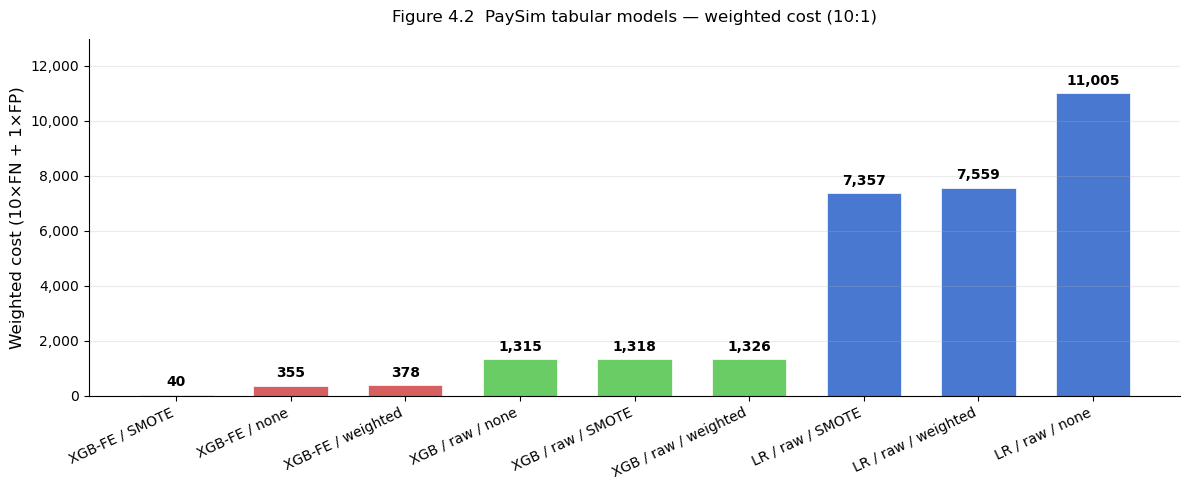

Saved: figures/fig_4_2_paysim_weighted_cost.png


In [48]:
# Figure — PaySim weighted cost
df_p = master_paysim.sort_values("weighted_cost").reset_index(drop=True)
colors_p = [FAMILY_COLORS[f] for f in df_p["family"]]

bar_chart(
    labels  = df_p["label"].tolist(),
    costs   = df_p["weighted_cost"].tolist(),
    colors  = colors_p,
    title   = "Figure 4.2  PaySim tabular models — weighted cost (10:1)",
    filename= "fig_4_2_paysim_weighted_cost.png",
    figsize =(12, 5),
)
legend_patches = [mpatches.Patch(color=c, label=f)
                  for f, c in FAMILY_COLORS.items()
                  if f in ["LR","XGB","XGB-FE"]]
plt.legend(handles=legend_patches, frameon=False)


---
## Section C — Tabular-only models on MM dataset (Table 4.2)

In [14]:
tabular_families = ["LR (MM-tabular)", "XGB (MM-tabular)"]
table_c = (master_mm[master_mm["family"].isin(tabular_families)]
           [["label","family","features","imbalance","fn","fp",
             "precision","recall","f1","weighted_cost"]]
           .sort_values("weighted_cost").reset_index(drop=True))

print("Table 4.2 — Tabular-only MM models (10:1 weighted cost)")
print("=" * 95)
print(table_c.to_string(index=False))
table_c.to_csv(TAB_DIR / "table_4_2_mm_tabular_10to1.csv", index=False)
print(f"\nSaved: table_4_2_mm_tabular_10to1.csv")
print(f"\nObservation: all tabular-only models have FP ~546-554 — near all-positive collapse")


Table 4.2 — Tabular-only MM models (10:1 weighted cost)
                label           family features imbalance  fn  fp  precision  recall     f1  weighted_cost
 LR-MM / raw / weight  LR (MM-tabular)      raw    weight   0 552     0.6250  1.0000 0.7692            552
  LR-MM / raw / SMOTE  LR (MM-tabular)      raw     smote   0 552     0.6250  1.0000 0.7692            552
    LR-MM / FE / none  LR (MM-tabular)       fe      none   0 552     0.6250  1.0000 0.7692            552
   LR-MM / raw / none  LR (MM-tabular)      raw      none   0 553     0.6246  1.0000 0.7689            553
  XGB-MM / FE / SMOTE XGB (MM-tabular)       fe     smote   0 553     0.6246  1.0000 0.7689            553
XGB-MM / raw / weight XGB (MM-tabular)      raw    weight   0 554     0.6242  1.0000 0.7686            554
 XGB-MM / raw / SMOTE XGB (MM-tabular)      raw     smote   0 554     0.6242  1.0000 0.7686            554
  XGB-MM / raw / none XGB (MM-tabular)      raw      none   0 554     0.6242  1.0000 0.7

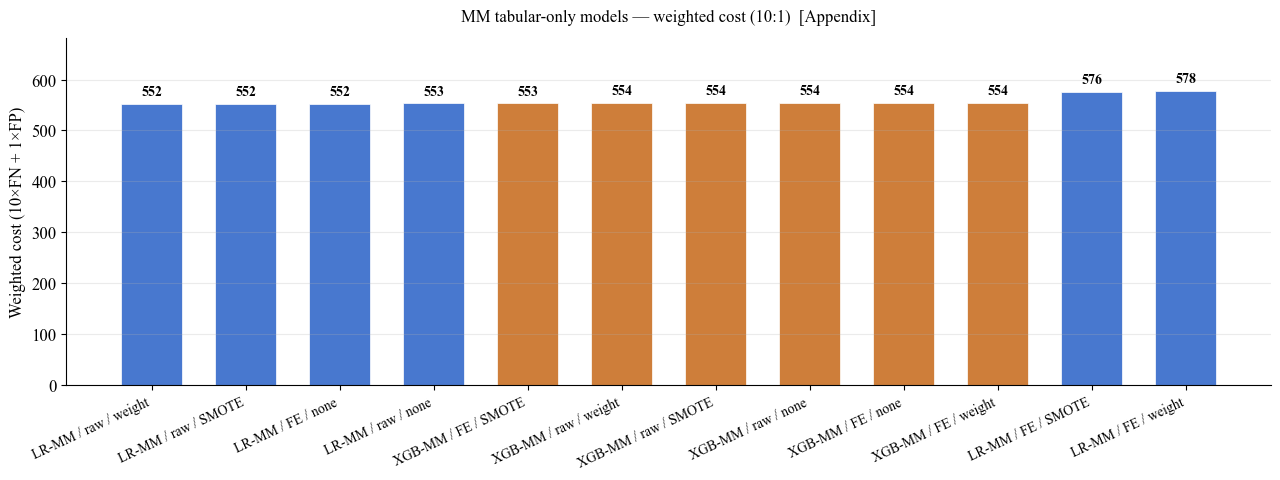

Saved: figures/fig_appendix_mm_tabular_cost.png
Note: placed in appendix — table already tells the story clearly


In [15]:
# Figure — MM tabular weighted cost (appendix)
df_c = table_c.copy()
colors_c = [FAMILY_COLORS[f] for f in df_c["family"]]
bar_chart(
    labels  = df_c["label"].tolist(),
    costs   = df_c["weighted_cost"].tolist(),
    colors  = colors_c,
    title   = "MM tabular-only models — weighted cost (10:1)  [Appendix]",
    filename= "fig_appendix_mm_tabular_cost.png",
    figsize =(13, 5),
)
print("Note: placed in appendix — table already tells the story clearly")


---
## Section D — Image-only baseline results (Table 4.3)

In [16]:
image_families = ["EfficientNet (image-only)", "ResNet-18 (image-only)"]
table_d = (master_mm[master_mm["family"].isin(image_families)]
           [["label","family","imbalance","fn","fp",
             "precision","recall","f1","weighted_cost"]]
           .sort_values("weighted_cost").reset_index(drop=True))

print("Table 4.3 — Image-only models (10:1 weighted cost)")
print("=" * 85)
print(table_d.to_string(index=False))
table_d.to_csv(TAB_DIR / "table_4_3_image_only_10to1.csv", index=False)
print(f"\nSaved: table_4_3_image_only_10to1.csv")


Table 4.3 — Image-only models (10:1 weighted cost)
                 label                    family imbalance  fn  fp  precision  recall     f1  weighted_cost
EfficientNet / sampler EfficientNet (image-only)   sampler   0 553     0.6246  1.0000 0.7689            553
   ResNet-18 / sampler    ResNet-18 (image-only)   sampler   0 554     0.6242  1.0000 0.7686            554
 EfficientNet / normal EfficientNet (image-only)    normal  12 521     0.6354  0.9870 0.7731            641
    ResNet-18 / normal    ResNet-18 (image-only)    normal  28 434     0.6727  0.9696 0.7943            714

Saved: table_4_3_image_only_10to1.csv


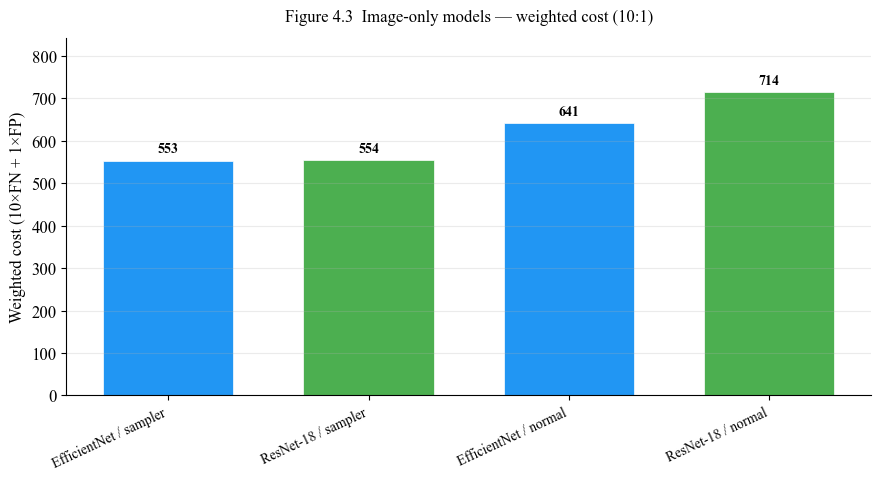

Saved: figures/fig_4_3_image_only_cost.png


In [17]:
df_d = table_d.copy()
colors_d = [FAMILY_COLORS[f] for f in df_d["family"]]
bar_chart(
    labels  = df_d["label"].tolist(),
    costs   = df_d["weighted_cost"].tolist(),
    colors  = colors_d,
    title   = "Figure 4.3  Image-only models — weighted cost (10:1)",
    filename= "fig_4_3_image_only_cost.png",
    figsize =(9, 5),
)


---
## Section E — Multimodal fusion results (Table 4.4)

In [18]:
fusion_families = ["Multimodal EfficientNet", "Multimodal ResNet-18"]
table_e = (master_mm[master_mm["family"].isin(fusion_families)]
           [["label","family","features","imbalance","fn","fp",
             "precision","recall","f1","weighted_cost"]]
           .sort_values("weighted_cost").reset_index(drop=True))

print("Table 4.4 — Multimodal fusion models (10:1 weighted cost)")
print("=" * 95)
print(table_e.to_string(index=False))
table_e.to_csv(TAB_DIR / "table_4_4_fusion_10to1.csv", index=False)
print(f"\nSaved: table_4_4_fusion_10to1.csv")


Table 4.4 — Multimodal fusion models (10:1 weighted cost)
                        label                  family features imbalance  fn  fp  precision  recall     f1  weighted_cost
  Fusion-EffNet / FE / normal Multimodal EfficientNet       fe    normal   1 151     0.8589  0.9989 0.9236            161
  Fusion-ResNet / FE / normal    Multimodal ResNet-18       fe    normal   4 147     0.8617  0.9957 0.9239            187
 Fusion-ResNet / FE / sampler    Multimodal ResNet-18       fe   sampler   3 170     0.8436  0.9967 0.9138            200
 Fusion-EffNet / FE / sampler Multimodal EfficientNet       fe   sampler   5 166     0.8464  0.9946 0.9145            216
 Fusion-EffNet / raw / normal Multimodal EfficientNet      raw    normal  12 148     0.8598  0.9870 0.9190            268
 Fusion-ResNet / raw / normal    Multimodal ResNet-18      raw    normal  10 177     0.8372  0.9891 0.9068            277
Fusion-ResNet / raw / sampler    Multimodal ResNet-18      raw   sampler   4 246     0.7

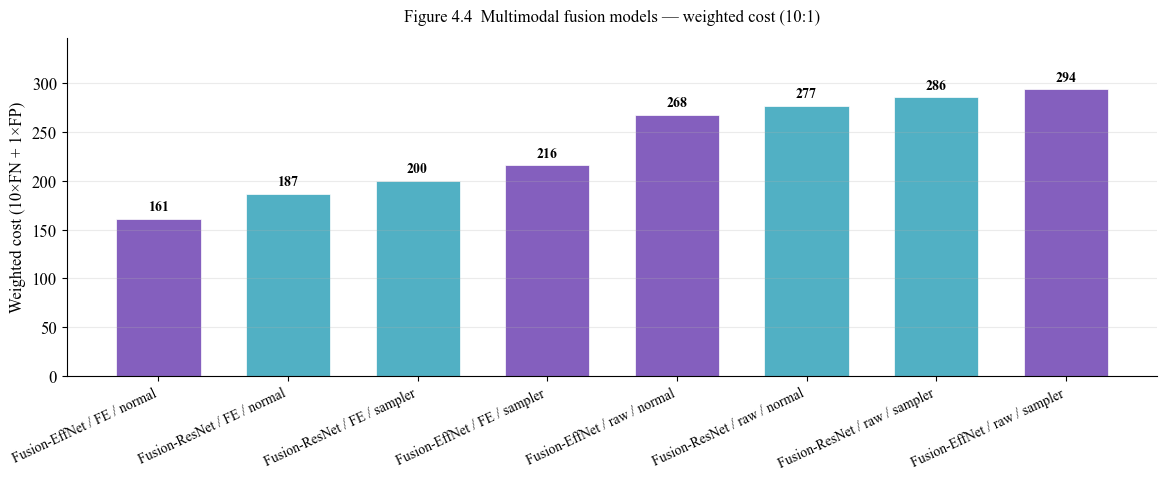

Saved: figures/fig_4_4_fusion_cost.png


In [19]:
df_e = table_e.copy()
colors_e = [FAMILY_COLORS[f] for f in df_e["family"]]
bar_chart(
    labels  = df_e["label"].tolist(),
    costs   = df_e["weighted_cost"].tolist(),
    colors  = colors_e,
    title   = "Figure 4.4  Multimodal fusion models — weighted cost (10:1)",
    filename= "fig_4_4_fusion_cost.png",
    figsize =(12, 5),
)


---
## Section F — Main comparison: best model per family (Figure 4.6, Table 4.5)

In [20]:
# Best per family from MM
best_mm = (master_mm.sort_values("weighted_cost")
           .groupby("family", sort=False).first().reset_index())

# Combine with PaySim best (for context only — different dataset)
best_paysim = (master_paysim.sort_values("weighted_cost")
               .groupby("family", sort=False).first().reset_index())

print("Best model per MM family:")
print(best_mm[["family","label","fn","fp","recall","precision","f1","weighted_cost"]].to_string(index=False))
best_mm.to_csv(TAB_DIR / "table_4_5_best_per_family_10to1.csv", index=False)
print(f"\nSaved: table_4_5_best_per_family_10to1.csv")


Best model per MM family:
                   family                       label  fn  fp  recall  precision     f1  weighted_cost
  Multimodal EfficientNet Fusion-EffNet / FE / normal   1 151  0.9989     0.8589 0.9236            161
     Multimodal ResNet-18 Fusion-ResNet / FE / normal   4 147  0.9957     0.8617 0.9239            187
          LR (MM-tabular)        LR-MM / raw / weight   0 552  1.0000     0.6250 0.7692            552
EfficientNet (image-only)      EfficientNet / sampler   0 553  1.0000     0.6246 0.7689            553
         XGB (MM-tabular)         XGB-MM / FE / SMOTE   0 553  1.0000     0.6246 0.7689            553
   ResNet-18 (image-only)         ResNet-18 / sampler   0 554  1.0000     0.6242 0.7686            554

Saved: table_4_5_best_per_family_10to1.csv


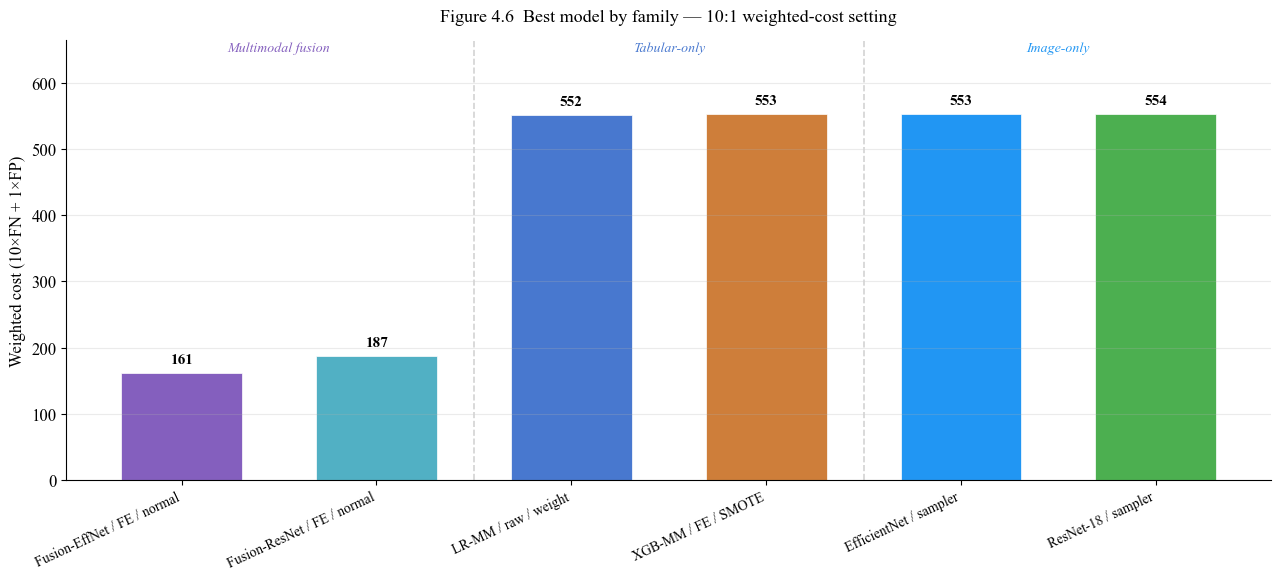

Saved: figures/fig_4_6_best_per_family.png


In [22]:
# ── Main thesis figure — best per family ─────────────────────────────────────
family_order = [
    "Multimodal EfficientNet",
    "Multimodal ResNet-18",
    "LR (MM-tabular)",
    "XGB (MM-tabular)",
    "EfficientNet (image-only)",
    "ResNet-18 (image-only)",
]
group_map = {
    "Multimodal EfficientNet":   "Multimodal fusion",
    "Multimodal ResNet-18":      "Multimodal fusion",
    "LR (MM-tabular)":           "Tabular-only",
    "XGB (MM-tabular)":          "Tabular-only",
    "EfficientNet (image-only)": "Image-only",
    "ResNet-18 (image-only)":    "Image-only",
}

best_ordered = (best_mm.set_index("family")
                .loc[family_order].reset_index())
labels_f = best_ordered["label"].tolist()
costs_f  = best_ordered["weighted_cost"].tolist()
colors_f = [FAMILY_COLORS[f] for f in best_ordered["family"]]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(best_ordered)), costs_f, color=colors_f,
              edgecolor="white", linewidth=0.5, width=0.62)
ax.bar_label(bars, labels=[f"{v:,}" for v in costs_f],
             padding=5, fontsize=11, fontweight="bold")
ax.set_xticks(range(len(best_ordered)))
ax.set_xticklabels(labels_f, fontsize=10, rotation=25, ha="right")
ax.set_ylabel(COST_LABEL, fontsize=12)
ax.set_title("Figure 4.6  Best model by family — 10:1 weighted-cost setting",
             fontsize=13, pad=14)
ax.set_ylim(0, max(costs_f) * 1.20)
ax.yaxis.set_major_formatter(fmt_cost)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

# Group dividers and labels
ax.axvline(1.5, color="lightgrey", linewidth=1.2, linestyle="--")
ax.axvline(3.5, color="lightgrey", linewidth=1.2, linestyle="--")
y_top = max(costs_f) * 1.17
ax.text(0.5, y_top, "Multimodal fusion", ha="center", fontsize=10,
        color=FAMILY_COLORS["Multimodal EfficientNet"], style="italic")
ax.text(2.5, y_top, "Tabular-only", ha="center", fontsize=10,
        color=FAMILY_COLORS["LR (MM-tabular)"], style="italic")
ax.text(4.5, y_top, "Image-only", ha="center", fontsize=10,
        color=FAMILY_COLORS["EfficientNet (image-only)"], style="italic")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_6_best_per_family.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/fig_4_6_best_per_family.png")


---
## Section G — Sensitivity analysis across cost ratios (Table 4.6)

In [23]:
# Uses fixed FN/FP from 10:1 tuned threshold, varies cost weights
# This shows whether model ranking is robust to cost assumption

sens_rows = []
for _, row in master_mm.iterrows():
    for ratio, (fn_w, fp_w) in COST_RATIOS.items():
        cost = row["fn"] * fn_w + row["fp"] * fp_w
        collapsed = (row["tn"] <= 5)  # near all-positive
        sens_rows.append({
            "label":    row["label"],
            "family":   row["family"],
            "ratio":    ratio,
            "fn_w":     fn_w,
            "fp_w":     fp_w,
            "fn":       row["fn"],
            "fp":       row["fp"],
            "recall":   row["recall"],
            "cost":     cost,
            "collapsed":collapsed,
        })

sens_df = pd.DataFrame(sens_rows)

# Summary: best model per ratio
print("Best model per cost ratio:")
print("-" * 65)
for ratio in COST_RATIOS:
    sub = sens_df[sens_df["ratio"]==ratio].sort_values("cost")
    best = sub.iloc[0]
    print(f"  {ratio:6s}  best={best['label']:<35}  cost={best['cost']:>5,}  "
          f"recall={best['recall']:.4f}")

sens_df.to_csv(TAB_DIR / "table_4_6_sensitivity_all_ratios.csv", index=False)
print(f"\nSaved: table_4_6_sensitivity_all_ratios.csv")


Best model per cost ratio:
-----------------------------------------------------------------
  5:1     best=Fusion-EffNet / FE / normal          cost=  156  recall=0.9989
  10:1    best=Fusion-EffNet / FE / normal          cost=  161  recall=0.9989
  20:1    best=Fusion-EffNet / FE / normal          cost=  171  recall=0.9989
  50:1    best=Fusion-EffNet / FE / normal          cost=  201  recall=0.9989
  100:1   best=Fusion-EffNet / FE / normal          cost=  251  recall=0.9989

Saved: table_4_6_sensitivity_all_ratios.csv


In [24]:
# Sensitivity pivot table
pivot = (sens_df.pivot_table(index="label", columns="ratio", values="cost", aggfunc="first")
         .loc[:, list(COST_RATIOS.keys())])
pivot = pivot.loc[master_mm.sort_values("weighted_cost")["label"].tolist()]
print("Sensitivity pivot (cost by ratio):")
print(pivot.to_string())
pivot.to_csv(TAB_DIR / "table_4_6_sensitivity_pivot.csv")

# Collapse summary
collapse_summary = (sens_df.groupby(["label","family"])
                    .apply(lambda x: x[x["collapsed"]]["ratio"].tolist())
                    .reset_index(name="collapses_at"))
print("\nCollapse summary (TN≤5):")
print(collapse_summary[collapse_summary["collapses_at"].apply(len)>0].to_string(index=False))


Sensitivity pivot (cost by ratio):
ratio                          5:1  10:1  20:1  50:1  100:1
label                                                      
Fusion-EffNet / FE / normal    156   161   171   201    251
Fusion-ResNet / FE / normal    167   187   227   347    547
Fusion-ResNet / FE / sampler   185   200   230   320    470
Fusion-EffNet / FE / sampler   191   216   266   416    666
Fusion-EffNet / raw / normal   208   268   388   748   1348
Fusion-ResNet / raw / normal   227   277   377   677   1177
Fusion-ResNet / raw / sampler  266   286   326   446    646
Fusion-EffNet / raw / sampler  259   294   364   574    924
LR-MM / raw / weight           552   552   552   552    552
LR-MM / raw / SMOTE            552   552   552   552    552
LR-MM / FE / none              552   552   552   552    552
LR-MM / raw / none             553   553   553   553    553
EfficientNet / sampler         553   553   553   553    553
XGB-MM / FE / SMOTE            553   553   553   553    553
XGB-M

C:\Users\Admin\AppData\Local\Temp\ipykernel_8032\719420472.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x["collapsed"]]["ratio"].tolist())


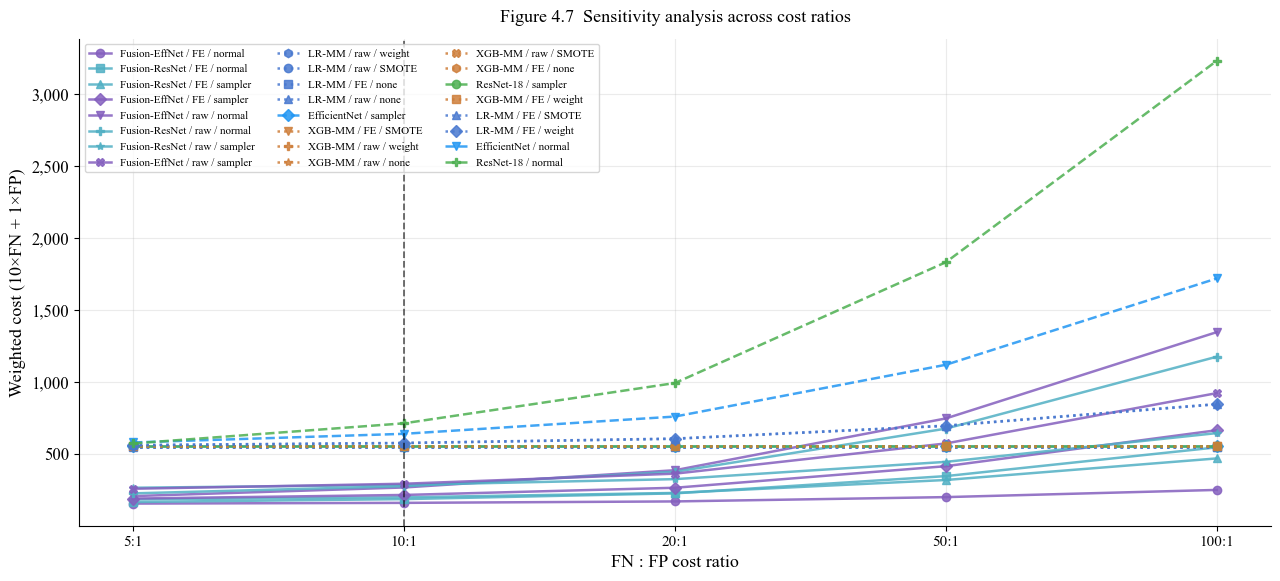

Saved: figures/fig_4_7_sensitivity_ratios.png


In [25]:
# Sensitivity line plot
fig, ax = plt.subplots(figsize=(13, 6))
ratios_sorted = list(COST_RATIOS.keys())
markers = ["o","s","^","D","v","P","*","X","h"]
ls_map  = {f: ("-" if "Multimodal" in f else "--" if "image" in f.lower() else ":")
           for f in master_mm["family"].unique()}

for i, (_, row) in enumerate(master_mm.sort_values("weighted_cost").iterrows()):
    costs_line = [row["fn"]*COST_RATIOS[r][0] + row["fp"]*COST_RATIOS[r][1]
                  for r in ratios_sorted]
    ax.plot(ratios_sorted, costs_line,
            marker=markers[i % len(markers)], linewidth=1.8, markersize=6,
            color=FAMILY_COLORS.get(row["family"],"grey"),
            linestyle=ls_map.get(row["family"],"-"),
            label=row["label"], alpha=0.85)

ax.axvline("10:1", color="black", linestyle="--", linewidth=1.3, alpha=0.6)
ax.set_xlabel("FN : FP cost ratio"); ax.set_ylabel(COST_LABEL)
ax.set_title("Figure 4.7  Sensitivity analysis across cost ratios", fontsize=13, pad=12)
ax.yaxis.set_major_formatter(fmt_cost)
ax.legend(fontsize=8, frameon=True, ncol=3, loc="upper left")
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_7_sensitivity_ratios.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/fig_4_7_sensitivity_ratios.png")


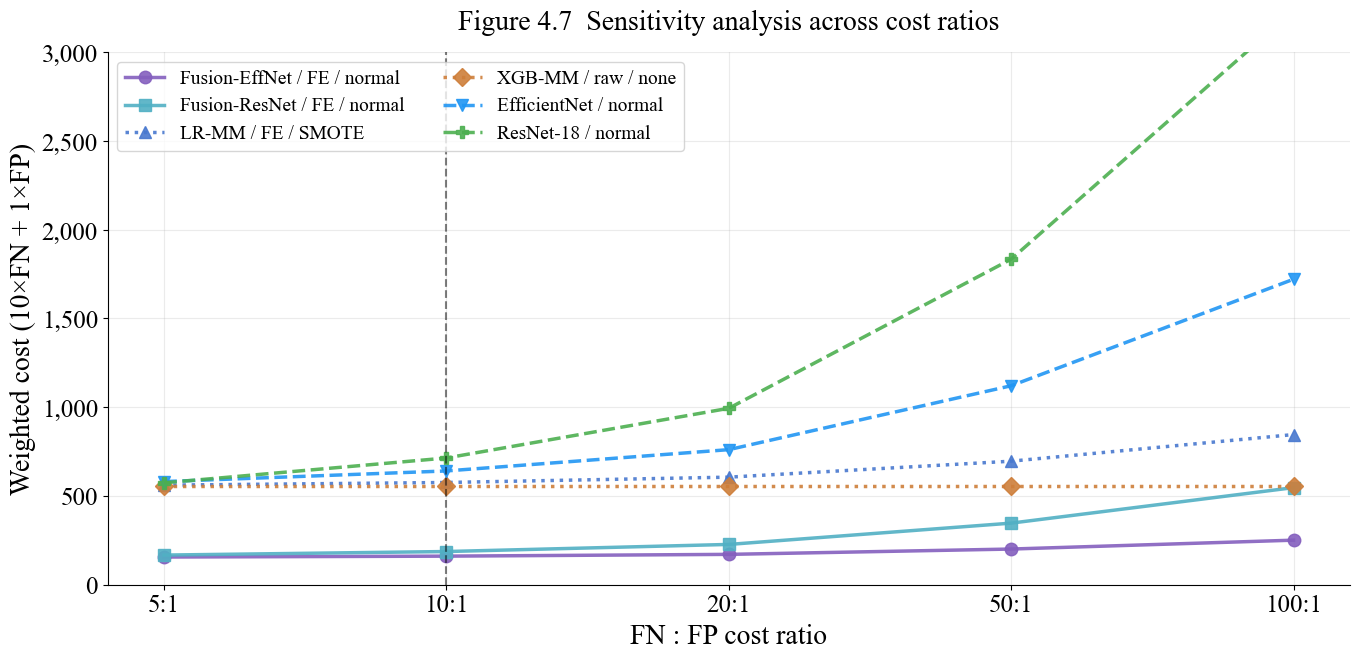

In [47]:
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":       20,
    "axes.titlesize":  20,
    "axes.labelsize":  20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

SELECTED_MODELS = [
    "Fusion-EffNet / FE / normal",
    "Fusion-ResNet / FE / normal",
    "LR-MM / FE / SMOTE",
    "XGB-MM / raw / none",
    "EfficientNet / normal",
    "ResNet-18 / normal",
]

selected = master_mm[master_mm["label"].isin(SELECTED_MODELS)].set_index("label").loc[SELECTED_MODELS].reset_index()

ratios_sorted = list(COST_RATIOS.keys())
markers   = ["o", "s", "^", "D", "v", "P"]
linestyle = {
    "Multimodal EfficientNet":   "-",
    "Multimodal ResNet-18":      "-",
    "LR (MM-tabular)":           ":",
    "XGB (MM-tabular)":          ":",
    "EfficientNet (image-only)": "--",
    "ResNet-18 (image-only)":    "--",
}

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(selected.iterrows()):
    costs_line = [row["fn"] * COST_RATIOS[r][0] + row["fp"] * COST_RATIOS[r][1]
                  for r in ratios_sorted]
    ax.plot(ratios_sorted, costs_line,
            marker=markers[i], linewidth=2.5, markersize=9,
            color=FAMILY_COLORS.get(row["family"], "grey"),
            linestyle=linestyle.get(row["family"], "-"),
            label=row["label"], alpha=0.9)

ax.axvline("10:1", color="black", linestyle="--", linewidth=1.5, alpha=0.5)
ax.set_ylim(0, 3000)
ax.set_xlabel("FN : FP cost ratio")
ax.set_ylabel(COST_LABEL)
ax.set_title("Figure 4.7  Sensitivity analysis across cost ratios", pad=16)
ax.yaxis.set_major_formatter(fmt_cost)
ax.legend(fontsize=14, frameon=True, loc="upper left", ncol=2)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_7_sensitivity_ratios.png", dpi=300, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

---
## Section H — Shared-constraint feasibility analysis (Tables 4.7, 4.8)

In [26]:
# ── H.1  Recall target: recall ≥ 0.99 ───────────────────────────────────────
# For each MM model, find threshold from cost_results.csv that gives recall ≥ 0.99
# then report resulting FP at that threshold

recall_target = 0.99
fp_budget     = 200

recall_rows = []
fp_rows     = []

for entry in MM_WHITELIST:
    folder, subfolder, prefix, mtype, label, family, features, imbalance = entry
    pred_path = nb_results / folder / subfolder / "test_predictions.csv"
    if not pred_path.exists():
        continue

    preds = pd.read_csv(pred_path)
    y_true = preds["y_true"].values
    y_prob = preds["y_prob"].values

    thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)
    results = []
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tp = int(((y_pred==1) & (y_true==1)).sum())
        fp = int(((y_pred==1) & (y_true==0)).sum())
        fn = int(((y_pred==0) & (y_true==1)).sum())
        tn = int(((y_pred==0) & (y_true==0)).sum())
        recall = tp / (tp+fn) if (tp+fn) > 0 else 0
        prec   = tp / (tp+fp) if (tp+fp) > 0 else 0
        results.append({"thr":thr,"tp":tp,"fp":fp,"fn":fn,"tn":tn,
                         "recall":recall,"precision":prec,
                         "cost":fn*FN_WEIGHT+fp*FP_WEIGHT})
    df_r = pd.DataFrame(results)

    # Recall target: lowest FP where recall >= 0.99
    feasible = df_r[df_r["recall"] >= recall_target]
    if len(feasible) > 0:
        best_rt = feasible.loc[feasible["fp"].idxmin()]
        recall_rows.append({"label":label,"family":family,
            "threshold":best_rt["thr"],"recall":round(best_rt["recall"],4),
            "fn":int(best_rt["fn"]),"fp":int(best_rt["fp"]),
            "precision":round(best_rt["precision"],4),
            "cost":int(best_rt["cost"])})
    else:
        recall_rows.append({"label":label,"family":family,
            "threshold":None,"recall":df_r["recall"].max(),
            "fn":None,"fp":None,"precision":None,"cost":None,
            "note":"recall<0.99 not achievable"})

    # FP budget: highest recall where FP <= 200
    feasible_fp = df_r[df_r["fp"] <= fp_budget]
    if len(feasible_fp) > 0:
        best_fp = feasible_fp.loc[feasible_fp["recall"].idxmax()]
        fp_rows.append({"label":label,"family":family,
            "threshold":best_fp["thr"],"recall":round(best_fp["recall"],4),
            "fn":int(best_fp["fn"]),"fp":int(best_fp["fp"]),
            "precision":round(best_fp["precision"],4),
            "cost":int(best_fp["cost"])})
    else:
        fp_rows.append({"label":label,"family":family,
            "threshold":None,"recall":None,"fn":None,"fp":None,
            "precision":None,"cost":None,
            "note":"FP always > 200"})

table_recall = pd.DataFrame(recall_rows).sort_values("fp")
table_fp     = pd.DataFrame(fp_rows).sort_values("recall", ascending=False)

print(f"Table 4.7 — Recall ≥ {recall_target} target (fewest FP)")
print(table_recall.to_string(index=False))
table_recall.to_csv(TAB_DIR / "table_4_7_feasibility_recall_099.csv", index=False)

print(f"\nTable 4.8 — FP ≤ {fp_budget} budget (highest recall)")
print(table_fp.to_string(index=False))
table_fp.to_csv(TAB_DIR / "table_4_8_feasibility_fp_budget_200.csv", index=False)
print("\nSaved both feasibility tables.")


Table 4.7 — Recall ≥ 0.99 target (fewest FP)
                        label                    family  threshold  recall  fn  fp  precision  cost
  Fusion-EffNet / FE / normal   Multimodal EfficientNet       0.19  0.9913   8 114     0.8889   194
  Fusion-ResNet / FE / normal      Multimodal ResNet-18       0.14  0.9935   6 124     0.8805   184
 Fusion-ResNet / FE / sampler      Multimodal ResNet-18       0.13  0.9902   9 132     0.8734   222
 Fusion-EffNet / FE / sampler   Multimodal EfficientNet       0.20  0.9913   8 144     0.8636   224
 Fusion-EffNet / raw / normal   Multimodal EfficientNet       0.07  0.9913   8 187     0.8298   267
 Fusion-ResNet / raw / normal      Multimodal ResNet-18       0.09  0.9924   7 196     0.8233   266
Fusion-ResNet / raw / sampler      Multimodal ResNet-18       0.13  0.9902   9 210     0.8127   300
Fusion-EffNet / raw / sampler   Multimodal EfficientNet       0.16  0.9913   8 214     0.8099   294
       EfficientNet / sampler EfficientNet (image-only)

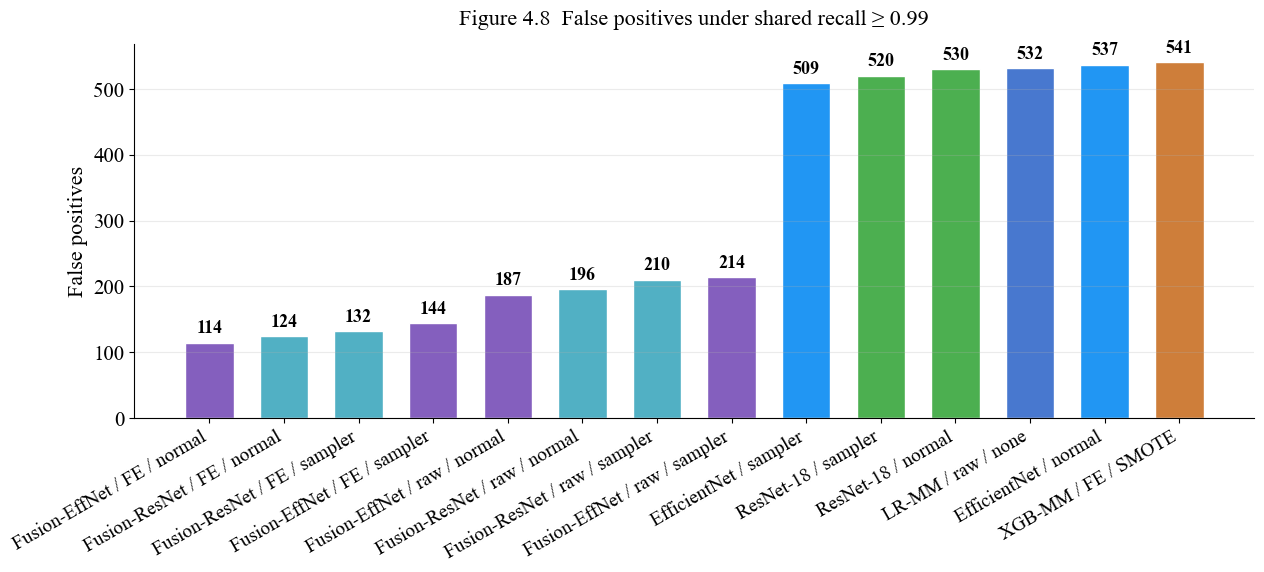

Saved: fig_4_8_feasibility_recall_target.png


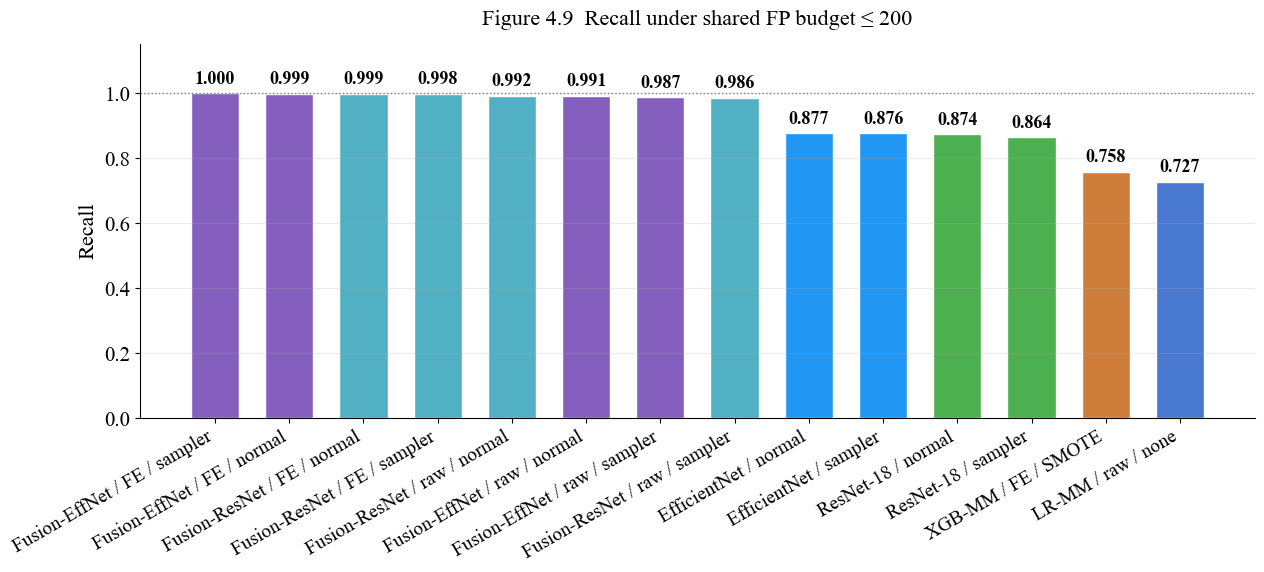

Saved: fig_4_9_feasibility_fp_budget.png


In [50]:
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":       16,
    "axes.titlesize":  16,
    "axes.labelsize":  16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})

# ── Figure 4.8 — FP under recall ≥ 0.99 ──────────────────────────────────────
df_rt     = table_recall.dropna(subset=["fp"]).sort_values("fp")
colors_rt = [FAMILY_COLORS.get(f, "grey") for f in df_rt["family"]]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(df_rt)), df_rt["fp"], color=colors_rt,
              edgecolor="white", width=0.65)
ax.bar_label(bars, labels=[f"{v:,}" for v in df_rt["fp"]],
             padding=4, fontsize=13, fontweight="bold")
ax.set_xticks(range(len(df_rt)))
ax.set_xticklabels(df_rt["label"], rotation=30, ha="right")
ax.set_ylabel("False positives")
ax.set_title(f"Figure 4.8  False positives under shared recall ≥ {recall_target}", pad=14)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_8_feasibility_recall_target.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_4_8_feasibility_recall_target.png")

# ── Figure 4.9 — Recall under FP ≤ 200 ───────────────────────────────────────
df_fp     = table_fp.dropna(subset=["recall"]).sort_values("recall", ascending=False)
colors_fp = [FAMILY_COLORS.get(f, "grey") for f in df_fp["family"]]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(df_fp)), df_fp["recall"], color=colors_fp,
              edgecolor="white", width=0.65)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in df_fp["recall"]],
             padding=4, fontsize=13, fontweight="bold")
ax.set_xticks(range(len(df_fp)))
ax.set_xticklabels(df_fp["label"], rotation=30, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.15)
ax.set_title(f"Figure 4.9  Recall under shared FP budget ≤ {fp_budget}", pad=14)
ax.axhline(1.0, color="grey", linewidth=1, linestyle=":")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_9_feasibility_fp_budget.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_4_9_feasibility_fp_budget.png")

plt.rcParams.update(plt.rcParamsDefault)

---
## Section I — Subgroup analysis (tab1_img0)

In [28]:
# Load subgroup data from deep model folders
subgroup_rows = []
for entry in MM_WHITELIST:
    folder, subfolder, prefix, mtype, label, family, features, imbalance = entry
    if family not in ["Multimodal EfficientNet", "Multimodal ResNet-18",
                      "EfficientNet (image-only)", "ResNet-18 (image-only)"]:
        continue
    sg_path = nb_results / folder / subfolder / "subgroup_combo_type.csv"
    if sg_path.exists():
        sg = pd.read_csv(sg_path)
        sg["label"] = label; sg["family"] = family
        subgroup_rows.append(sg)

if subgroup_rows:
    sg_df = pd.concat(subgroup_rows, ignore_index=True)
    print("Subgroup columns:", sg_df.columns.tolist())
    print(sg_df.head())

    # Focus on tab1_img0 if available
    key_cols = [c for c in sg_df.columns if "tab" in c.lower() or "combo" in c.lower()]
    print("\nSubgroup key columns:", key_cols)
    sg_df.to_csv(TAB_DIR / "table_4_9_subgroup_analysis.csv", index=False)
    print("Saved: table_4_9_subgroup_analysis.csv")
else:
    print("No subgroup_combo_type.csv found — subgroup analysis not available for these models.")
    print("Check if subgroup files exist in deep model subfolders.")


Subgroup columns: ['combo_type', 'n_rows', 'label', 'precision', 'recall', 'f1', 'roc_auc', 'family']
  combo_type  n_rows                  label  precision    recall        f1  \
0  tab0_img0     554  EfficientNet / normal        0.0  0.000000  0.000000   
1  tab0_img1     368  EfficientNet / normal        1.0  1.000000  1.000000   
2  tab1_img0     185  EfficientNet / normal        1.0  0.178378  0.302752   
3  tab1_img1     367  EfficientNet / normal        1.0  1.000000  1.000000   
4  tab0_img0     554     ResNet-18 / normal        0.0  0.000000  0.000000   

   roc_auc                     family  
0      NaN  EfficientNet (image-only)  
1      NaN  EfficientNet (image-only)  
2      NaN  EfficientNet (image-only)  
3      NaN  EfficientNet (image-only)  
4      NaN     ResNet-18 (image-only)  

Subgroup key columns: ['combo_type']
Saved: table_4_9_subgroup_analysis.csv


In [53]:
LABEL_SHORT = {
    "Fusion-EffNet / FE / normal":   "Fusion-EffNet FE",
    "Fusion-ResNet / FE / normal":   "Fusion-ResNet FE",
    "Fusion-ResNet / FE / sampler":  "Fusion-ResNet FE+S",
    "Fusion-EffNet / FE / sampler":  "Fusion-EffNet FE+S",
    "Fusion-EffNet / raw / normal":  "Fusion-EffNet raw",
    "Fusion-ResNet / raw / normal":  "Fusion-ResNet raw",
    "EfficientNet / sampler":        "EffNet image+S",
    "ResNet-18 / sampler":           "ResNet image+S",
    "LR-MM / raw / none":            "LR-MM",
    "XGB-MM / FE / SMOTE":           "XGB-MM",
}



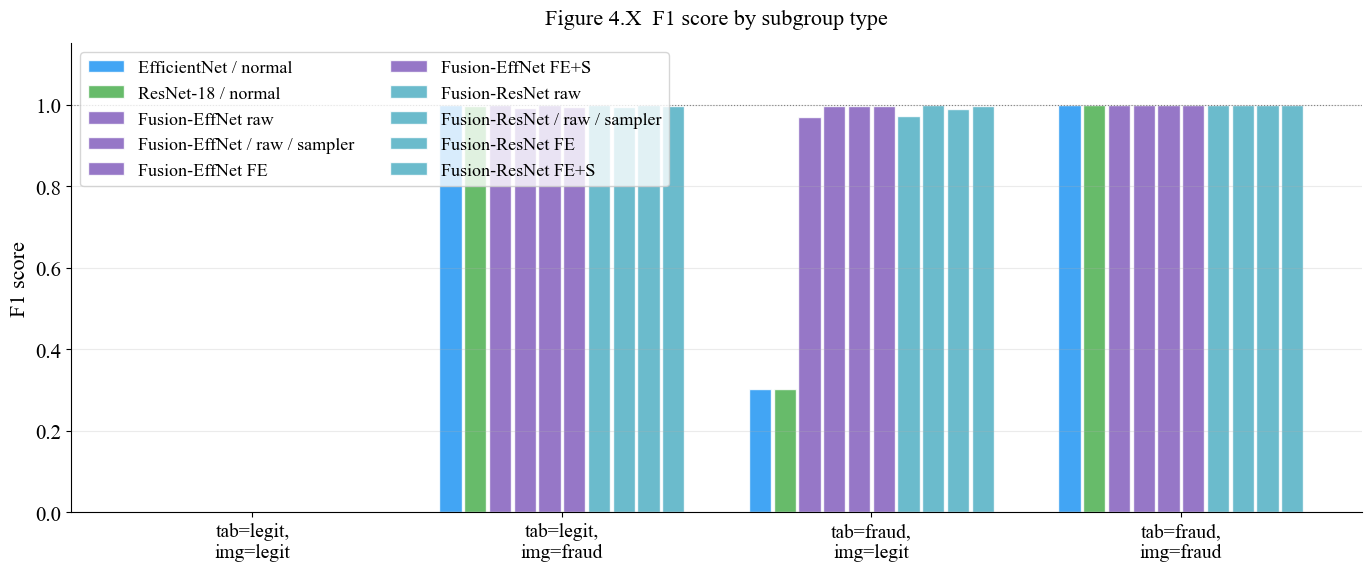

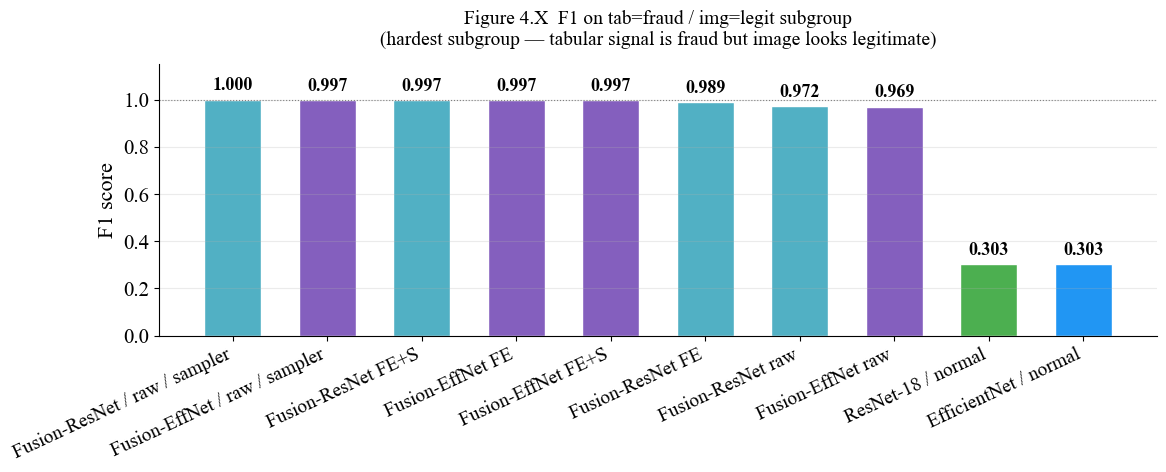

Saved both subgroup figures.


In [55]:
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":       16,
    "axes.titlesize":  16,
    "axes.labelsize":  16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})

COMBO_LABELS = {
    "tab0_img0": "tab=legit,\nimg=legit",
    "tab0_img1": "tab=legit,\nimg=fraud",
    "tab1_img0": "tab=fraud,\nimg=legit",
    "tab1_img1": "tab=fraud,\nimg=fraud",
}
sg_df["combo_label"] = sg_df["combo_type"].map(COMBO_LABELS)

# ── Figure 4.X  F1 by subgroup — all models ───────────────────────────────────
models_in_sg  = sg_df["label"].unique()
combo_types   = ["tab0_img0", "tab0_img1", "tab1_img0", "tab1_img1"]
combo_display = [COMBO_LABELS[c] for c in combo_types]

x     = np.arange(len(combo_types))
width = 0.8 / len(models_in_sg)

fig, ax = plt.subplots(figsize=(14, 6))

for i, model_label in enumerate(models_in_sg):
    sub    = sg_df[sg_df["label"] == model_label].set_index("combo_type")
    family = sg_df[sg_df["label"] == model_label]["family"].values[0]
    f1_vals = [sub.loc[c, "f1"] if c in sub.index else 0 for c in combo_types]
    offset  = (i - len(models_in_sg) / 2 + 0.5) * width
    short   = LABEL_SHORT.get(model_label, model_label)
    ax.bar(x + offset, f1_vals, width * 0.9,
           label=short, color=FAMILY_COLORS.get(family, "grey"),
           alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(combo_display)
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("Figure 4.X  F1 score by subgroup type", pad=14)
ax.legend(frameon=True, ncol=2, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_x_subgroup_f1_all.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure 4.X  Focus on tab1_img0 — the hardest subgroup ────────────────────
sg_tab1_img0 = sg_df[sg_df["combo_type"] == "tab1_img0"].sort_values("f1", ascending=False)
colors_sg    = [FAMILY_COLORS.get(f, "grey") for f in sg_tab1_img0["family"]]
short_labels = [LABEL_SHORT.get(l, l) for l in sg_tab1_img0["label"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(sg_tab1_img0)), sg_tab1_img0["f1"],
              color=colors_sg, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in sg_tab1_img0["f1"]],
             padding=4, fontsize=13, fontweight="bold")
ax.set_xticks(range(len(sg_tab1_img0)))
ax.set_xticklabels(short_labels, rotation=25, ha="right")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("Figure 4.X  F1 on tab=fraud / img=legit subgroup\n"
             "(hardest subgroup — tabular signal is fraud but image looks legitimate)",
             fontsize=14, pad=14)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_x_subgroup_tab1_img0.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved both subgroup figures.")
plt.rcParams.update(plt.rcParamsDefault)

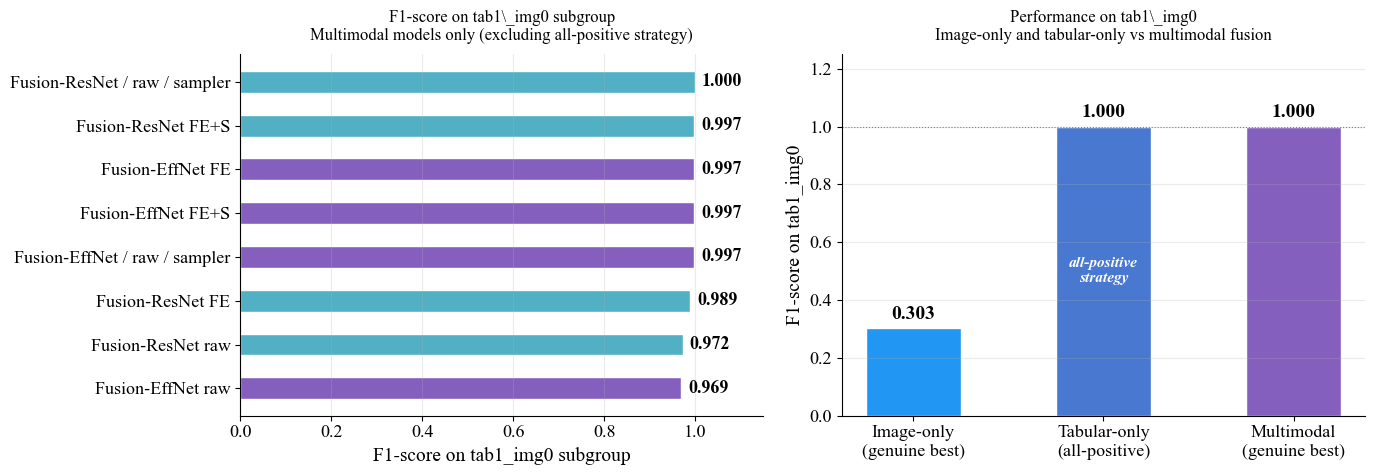

Saved: fig_4_x_subgroup_tab1_img0_comparison.png


In [56]:
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":      15,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize":13,
    "ytick.labelsize":13,
    "legend.fontsize":12,
})

# ── Data for each panel ───────────────────────────────────────────────────────
tab1_img0 = sg_df[sg_df["combo_type"] == "tab1_img0"].copy()

# Left panel: multimodal only, genuine (non-collapsed) — horizontal bars
multimodal_sg = (tab1_img0[tab1_img0["family"].isin(
                    ["Multimodal EfficientNet", "Multimodal ResNet-18"])]
                 .sort_values("f1", ascending=True))

# Right panel: best genuine per group
best_image    = tab1_img0[tab1_img0["family"].isin(
                    ["EfficientNet (image-only)", "ResNet-18 (image-only)"])]["f1"].max()
best_multimodal = tab1_img0[tab1_img0["family"].isin(
                    ["Multimodal EfficientNet", "Multimodal ResNet-18"])]["f1"].max()
# Tabular-only collapses to all-positive on tab1_img0 (all rows are fraud → F1=1.0)
tabular_f1 = 1.0

# ── Two-panel figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: horizontal bar — multimodal only ────────────────────────────────────
ax = axes[0]
family_labels = [LABEL_SHORT.get(l, l) for l in multimodal_sg["label"]]
colors_left   = [FAMILY_COLORS.get(f, "grey") for f in multimodal_sg["family"]]
bars = ax.barh(family_labels, multimodal_sg["f1"],
               color=colors_left, edgecolor="white", height=0.5)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in multimodal_sg["f1"]],
             padding=5, fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.15)
ax.set_xlabel("F1-score on tab1_img0 subgroup")
ax.set_title("F1-score on tab1\\_img0 subgroup\nMultimodal models only"
             " (excluding all-positive strategy)", fontsize=12, pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)

# ── Right: vertical bar — three-group comparison ──────────────────────────────
ax = axes[1]
group_labels = ["Image-only\n(genuine best)",
                "Tabular-only\n(all-positive)",
                "Multimodal\n(genuine best)"]
group_values = [best_image, tabular_f1, best_multimodal]
group_colors = [FAMILY_COLORS["EfficientNet (image-only)"],
                FAMILY_COLORS["LR (MM-tabular)"],
                FAMILY_COLORS["Multimodal EfficientNet"]]

bars = ax.bar(group_labels, group_values, color=group_colors,
              edgecolor="white", width=0.5)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in group_values],
             padding=4, fontsize=14, fontweight="bold")

# Annotate the all-positive bar
ax.text(1, 0.5, "all-positive\nstrategy", ha="center", va="center",
        fontsize=11, color="white", style="italic", fontweight="bold")

ax.set_ylim(0, 1.25)
ax.set_ylabel("F1-score on tab1_img0")
ax.set_title("Performance on tab1\\_img0\n"
             "Image-only and tabular-only vs multimodal fusion",
             fontsize=12, pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle=":")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_x_subgroup_tab1_img0_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_4_x_subgroup_tab1_img0_comparison.png")

plt.rcParams.update(plt.rcParamsDefault)

---
## Section J — Threshold tuning simulation

In [29]:
# Use best fusion model: Fusion-EffNet / FE / normal
best_fusion_entry = next(e for e in MM_WHITELIST
                         if e[4] == "Fusion-EffNet / FE / normal")
folder, subfolder = best_fusion_entry[0], best_fusion_entry[1]
pred_path = nb_results / folder / subfolder / "test_predictions.csv"

preds = pd.read_csv(pred_path)
y_true_sim = preds["y_true"].values
y_prob_sim = preds["y_prob"].values

# Simulate: no model / default 0.5 / tuned threshold
best_tuned_thr = master_mm[master_mm["label"]=="Fusion-EffNet / FE / normal"]["threshold"].values[0]

thresholds_sim = np.round(np.arange(0.01, 0.99, 0.01), 2)
sim_results = []
for thr in thresholds_sim:
    y_pred = (y_prob_sim >= thr).astype(int)
    tp=int(((y_pred==1)&(y_true_sim==1)).sum()); fp=int(((y_pred==1)&(y_true_sim==0)).sum())
    fn=int(((y_pred==0)&(y_true_sim==1)).sum()); tn=int(((y_pred==0)&(y_true_sim==0)).sum())
    sim_results.append({"threshold":thr,"fn":fn,"fp":fp,
                         "cost":fn*FN_WEIGHT+fp*FP_WEIGHT})
sim_df = pd.DataFrame(sim_results)

# Three scenarios
cost_no_model = int(y_true_sim.sum()) * FN_WEIGHT  # all predicted legit
cost_default  = sim_df[sim_df["threshold"]==0.50]["cost"].values[0]
cost_tuned    = sim_df.loc[sim_df["cost"].idxmin()]["cost"]

print("Threshold tuning simulation — Fusion-EffNet / FE / normal")
print(f"  No model (flag nothing) : cost = {cost_no_model:,}")
print(f"  Default threshold 0.50  : cost = {cost_default:,}")
print(f"  Tuned threshold {best_tuned_thr:.2f}     : cost = {cost_tuned:,}")
print(f"  Reduction (default→tuned): {(cost_default-cost_tuned)/cost_default*100:.1f}%")


Threshold tuning simulation — Fusion-EffNet / FE / normal
  No model (flag nothing) : cost = 9,200
  Default threshold 0.50  : cost = 1,466
  Tuned threshold 0.10     : cost = 152.0
  Reduction (default→tuned): 89.6%


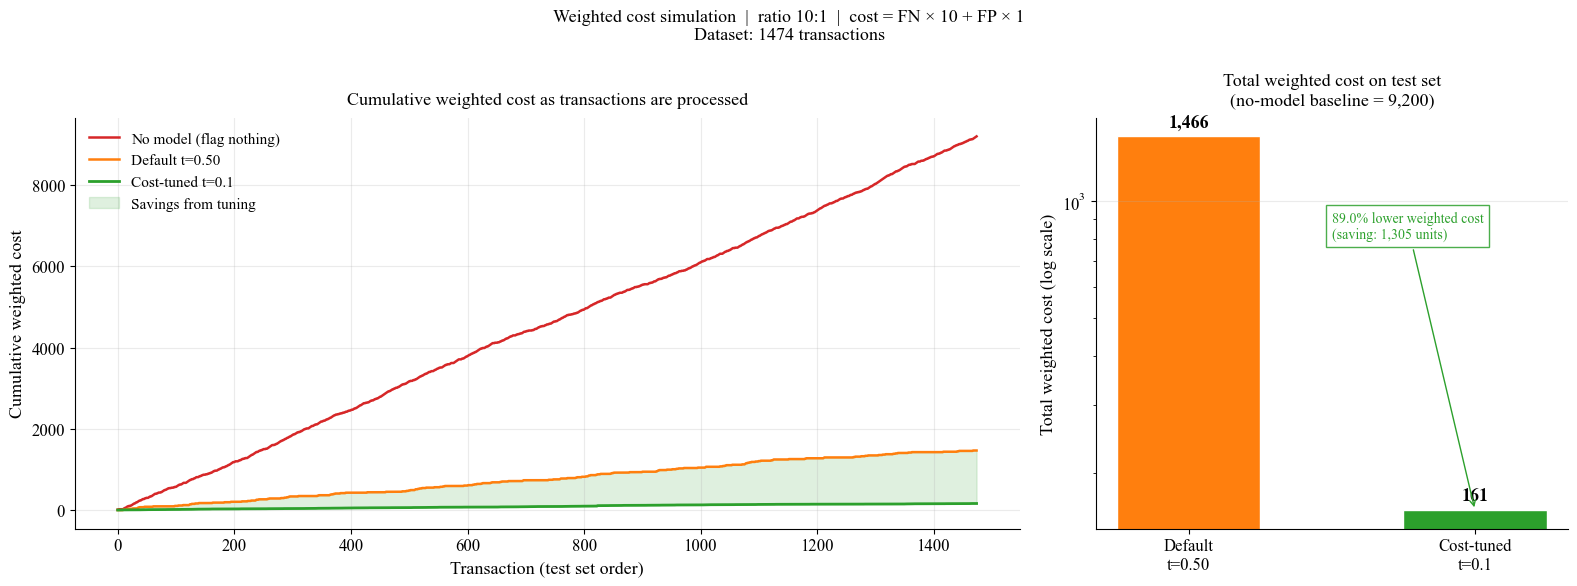

Saved: fig_4_10_threshold_simulation.png


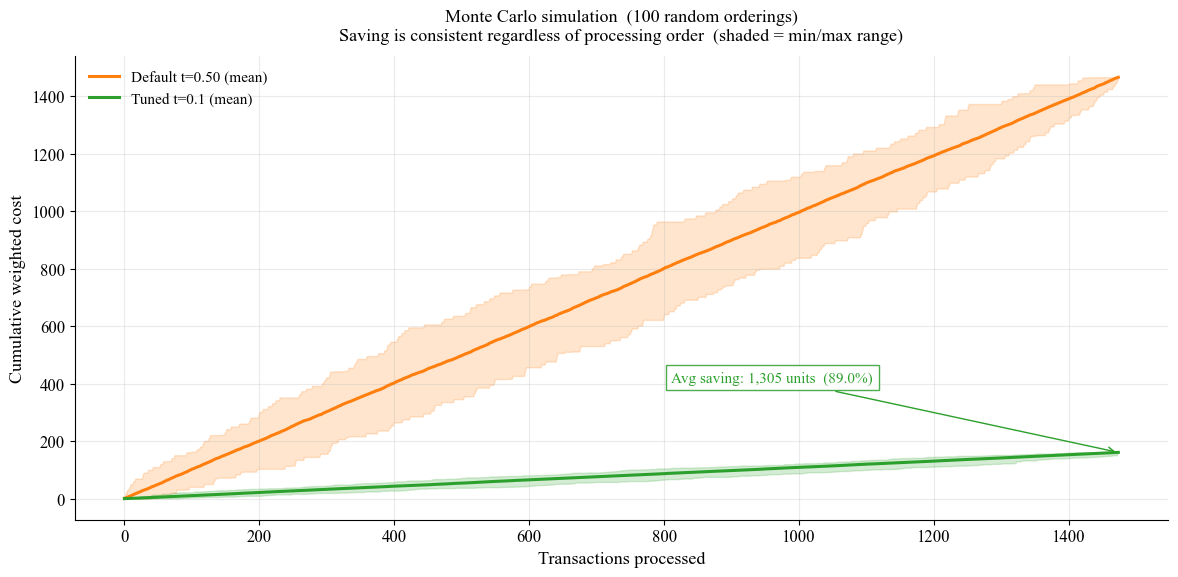

Saved: fig_appendix_monte_carlo.png


In [57]:
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":       14,
    "axes.titlesize":  13,
    "axes.labelsize":  13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

# ── Predictions at each threshold ─────────────────────────────────────────────
best_tuned_thr = float(master_mm[master_mm["label"] == "Fusion-EffNet / FE / normal"]["threshold"].values[0])

y_pred_default = (y_prob_sim >= 0.50).astype(int)
y_pred_tuned   = (y_prob_sim >= best_tuned_thr).astype(int)

def transaction_cost(y_true, y_pred, fn_w=FN_WEIGHT, fp_w=FP_WEIGHT):
    """Per-transaction cost: FN=fn_w, FP=fp_w, correct=0."""
    cost = np.zeros(len(y_true))
    cost[(y_pred == 0) & (y_true == 1)] = fn_w  # missed fraud
    cost[(y_pred == 1) & (y_true == 0)] = fp_w  # false alarm
    return cost

costs_no_model = transaction_cost(y_true_sim, np.zeros_like(y_true_sim))
costs_default  = transaction_cost(y_true_sim, y_pred_default)
costs_tuned    = transaction_cost(y_true_sim, y_pred_tuned)

cum_no_model = np.cumsum(costs_no_model)
cum_default  = np.cumsum(costs_default)
cum_tuned    = np.cumsum(costs_tuned)

total_no_model = int(cum_no_model[-1])
total_default  = int(cum_default[-1])
total_tuned    = int(cum_tuned[-1])
saving_pct     = (total_default - total_tuned) / total_default * 100
saving_units   = total_default - total_tuned

# ── Figure 1: Cumulative cost + bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [2, 1]})

# Left panel — cumulative cost curves
ax = axes[0]
x_idx = np.arange(len(y_true_sim))
ax.plot(x_idx, cum_no_model, color="#d62728", linewidth=1.8,
        linestyle="-", label="No model (flag nothing)")
ax.plot(x_idx, cum_default,  color="#ff7f0e", linewidth=1.8,
        linestyle="-", label=f"Default t=0.50")
ax.plot(x_idx, cum_tuned,    color="#2ca02c", linewidth=2.0,
        linestyle="-", label=f"Cost-tuned t={best_tuned_thr}")
ax.fill_between(x_idx, cum_tuned, cum_default,
                alpha=0.15, color="#2ca02c", label="Savings from tuning")
ax.set_xlabel("Transaction (test set order)")
ax.set_ylabel("Cumulative weighted cost")
ax.set_title("Cumulative weighted cost as transactions are processed", pad=10)
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)

# Right panel — total cost bar chart (log scale)
ax = axes[1]
bars = ax.bar(["Default\nt=0.50", f"Cost-tuned\nt={best_tuned_thr}"],
              [total_default, total_tuned],
              color=["#ff7f0e", "#2ca02c"], edgecolor="white", width=0.5)
ax.bar_label(bars, labels=[f"{total_default:,}", f"{total_tuned:,}"],
             padding=4, fontsize=13, fontweight="bold")
ax.set_yscale("log")
ax.set_ylabel("Total weighted cost (log scale)")
ax.set_title(f"Total weighted cost on test set\n(no-model baseline = {total_no_model:,})", pad=10)
ax.annotate(f"{saving_pct:.1f}% lower weighted cost\n(saving: {saving_units:,} units)",
            xy=(1, total_tuned), xytext=(0.5, total_tuned * 5),
            fontsize=10, color="#2ca02c",
            arrowprops=dict(arrowstyle="->", color="#2ca02c"),
            bbox=dict(facecolor="white", edgecolor="#2ca02c", alpha=0.85))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    f"Weighted cost simulation  |  ratio 10:1  |  cost = FN × {FN_WEIGHT} + FP × {FP_WEIGHT}\n"
    f"Dataset: {len(y_true_sim)} transactions",
    fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_10_threshold_simulation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_4_10_threshold_simulation.png")

# ── Figure 2: Monte Carlo simulation (100 random orderings) ───────────────────
N_RUNS = 100
n      = len(y_true_sim)
mc_default = np.zeros((N_RUNS, n))
mc_tuned   = np.zeros((N_RUNS, n))

np.random.seed(42)
for run in range(N_RUNS):
    idx = np.random.permutation(n)
    mc_default[run] = np.cumsum(costs_default[idx])
    mc_tuned[run]   = np.cumsum(costs_tuned[idx])

mean_default = mc_default.mean(axis=0)
min_default  = mc_default.min(axis=0)
max_default  = mc_default.max(axis=0)
mean_tuned   = mc_tuned.mean(axis=0)
min_tuned    = mc_tuned.min(axis=0)
max_tuned    = mc_tuned.max(axis=0)

avg_saving     = int(mean_default[-1] - mean_tuned[-1])
avg_saving_pct = avg_saving / mean_default[-1] * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(x_idx, min_default, max_default, alpha=0.2, color="#ff7f0e")
ax.fill_between(x_idx, min_tuned,   max_tuned,   alpha=0.2, color="#2ca02c")
ax.plot(x_idx, mean_default, color="#ff7f0e", linewidth=2.2,
        label=f"Default t=0.50 (mean)")
ax.plot(x_idx, mean_tuned,   color="#2ca02c", linewidth=2.2,
        label=f"Tuned t={best_tuned_thr} (mean)")

# Annotation arrow
mid = n // 2
ax.annotate(
    f"Avg saving: {avg_saving:,} units  ({avg_saving_pct:.1f}%)",
    xy=(n - 1, mean_tuned[-1]),
    xytext=(n * 0.55, (mean_default[n//2] + mean_tuned[n//2]) / 2),
    fontsize=11, color="#2ca02c",
    arrowprops=dict(arrowstyle="->", color="#2ca02c"),
    bbox=dict(facecolor="white", edgecolor="#2ca02c", alpha=0.85)
)

ax.set_xlabel("Transactions processed")
ax.set_ylabel("Cumulative weighted cost")
ax.set_title(
    f"Monte Carlo simulation  ({N_RUNS} random orderings)\n"
    "Saving is consistent regardless of processing order  (shaded = min/max range)",
    pad=12)
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(APP_DIR / "fig_appendix_monte_carlo.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_appendix_monte_carlo.png")

plt.rcParams.update(plt.rcParamsDefault)

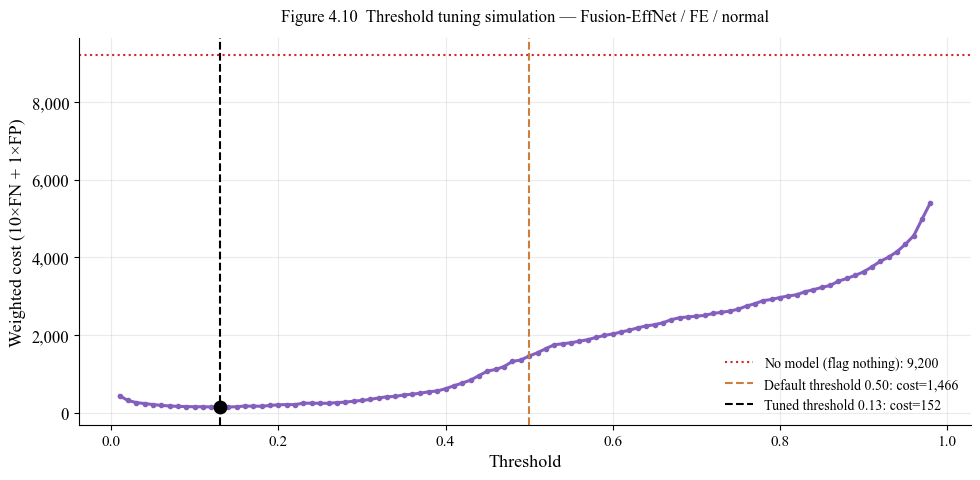

Saved: figures/fig_4_10_threshold_simulation.png


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sim_df["threshold"], sim_df["cost"], linewidth=2.2, color="#845fbe",
        marker="o", markersize=3)
ax.axhline(cost_no_model, color="#d62728", linewidth=1.5, linestyle=":",
           label=f"No model (flag nothing): {cost_no_model:,}")
ax.axvline(0.50, color="#ce7e3a", linewidth=1.5, linestyle="--",
           label=f"Default threshold 0.50: cost={cost_default:,}")
best_row = sim_df.loc[sim_df["cost"].idxmin()]
ax.axvline(best_row["threshold"], color="black", linewidth=1.5, linestyle="--",
           label=f"Tuned threshold {best_row['threshold']:.2f}: cost={int(best_row['cost']):,}")
ax.scatter(best_row["threshold"], best_row["cost"], s=80, color="black", zorder=5)

ax.set_xlabel("Threshold"); ax.set_ylabel(COST_LABEL)
ax.set_title("Figure 4.10  Threshold tuning simulation — Fusion-EffNet / FE / normal",
             fontsize=12, pad=12)
ax.yaxis.set_major_formatter(fmt_cost)
ax.legend(frameon=False, fontsize=10)
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_10_threshold_simulation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/fig_4_10_threshold_simulation.png")


---
## Section K — Effect of feature engineering

In [31]:
# Paired comparison: raw vs FE for XGB-MM and Fusion models
fe_pairs = [
    ("XGB-MM / raw / none",       "XGB-MM / FE / none"),
    ("XGB-MM / raw / SMOTE",      "XGB-MM / FE / SMOTE"),
    ("Fusion-EffNet / raw / normal","Fusion-EffNet / FE / normal"),
    ("Fusion-ResNet / raw / normal","Fusion-ResNet / FE / normal"),
]

fe_rows = []
mm_idx = master_mm.set_index("label")
for raw_label, fe_label in fe_pairs:
    if raw_label not in mm_idx.index or fe_label not in mm_idx.index:
        continue
    raw = mm_idx.loc[raw_label]
    fe  = mm_idx.loc[fe_label]
    fe_rows.append({
        "Model (raw)":   raw_label,
        "Model (FE)":    fe_label,
        "Cost raw":      raw["weighted_cost"],
        "Cost FE":       fe["weighted_cost"],
        "Improvement":   raw["weighted_cost"] - fe["weighted_cost"],
        "Improvement %": f"{(raw['weighted_cost']-fe['weighted_cost'])/raw['weighted_cost']*100:.1f}%",
    })

fe_df = pd.DataFrame(fe_rows)
print("Table 4.10 — Feature engineering effect")
print(fe_df.to_string(index=False))
fe_df.to_csv(TAB_DIR / "table_4_10_feature_engineering.csv", index=False)
print("\nSaved: table_4_10_feature_engineering.csv")


Table 4.10 — Feature engineering effect
                 Model (raw)                  Model (FE)  Cost raw  Cost FE  Improvement Improvement %
         XGB-MM / raw / none          XGB-MM / FE / none       554      554            0          0.0%
        XGB-MM / raw / SMOTE         XGB-MM / FE / SMOTE       554      553            1          0.2%
Fusion-EffNet / raw / normal Fusion-EffNet / FE / normal       268      161          107         39.9%
Fusion-ResNet / raw / normal Fusion-ResNet / FE / normal       277      187           90         32.5%

Saved: table_4_10_feature_engineering.csv


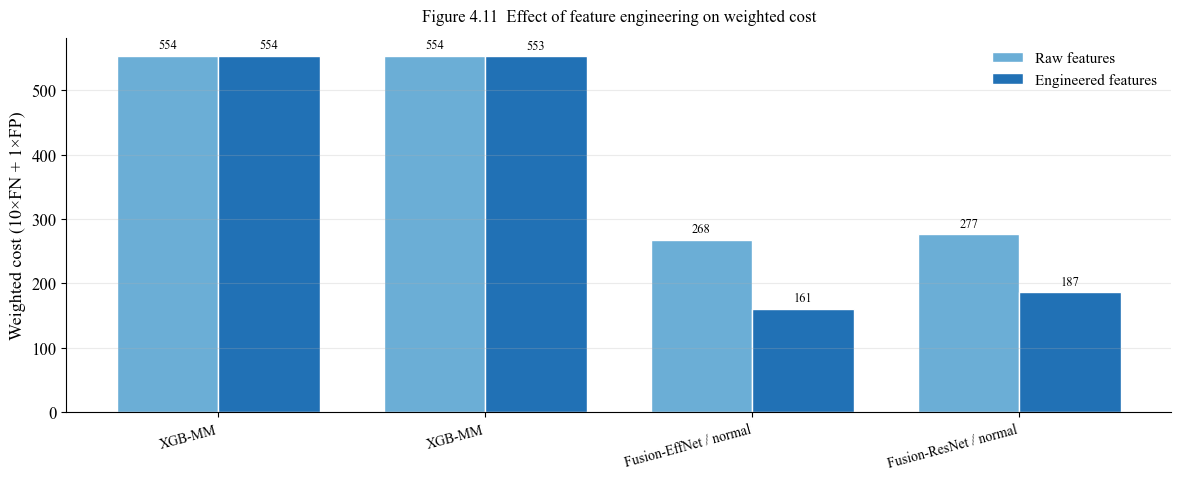

Saved: figures/fig_4_11_feature_engineering.png


In [32]:
# FE effect bar chart
x = np.arange(len(fe_rows)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x-w/2, fe_df["Cost raw"], w, label="Raw features",
            color="#6BAED6", edgecolor="white")
b2 = ax.bar(x+w/2, fe_df["Cost FE"],  w, label="Engineered features",
            color="#2171B5", edgecolor="white")
ax.bar_label(b1, labels=[f"{v:,}" for v in fe_df["Cost raw"]], padding=3, fontsize=9)
ax.bar_label(b2, labels=[f"{v:,}" for v in fe_df["Cost FE"]],  padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([r.replace(" / raw","").replace(" / none","").replace(" / SMOTE","")
                    for r in fe_df["Model (raw)"]], fontsize=10, rotation=15, ha="right")
ax.set_ylabel(COST_LABEL); ax.yaxis.set_major_formatter(fmt_cost)
ax.set_title("Figure 4.11  Effect of feature engineering on weighted cost", fontsize=12, pad=12)
ax.legend(frameon=False, fontsize=11)
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_11_feature_engineering.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/fig_4_11_feature_engineering.png")


---
## Section L — Effect of WeightedRandomSampler

In [33]:
# Sampler pairs — build from master_mm
sampler_pairs = [
    ("EfficientNet / normal",        "EfficientNet / sampler"),
    ("ResNet-18 / normal",           "ResNet-18 / sampler"),
    ("Fusion-EffNet / raw / normal", "Fusion-EffNet / raw / sampler"),
    ("Fusion-EffNet / FE / normal",  "Fusion-EffNet / FE / sampler"),
    ("Fusion-ResNet / raw / normal", "Fusion-ResNet / raw / sampler"),
    ("Fusion-ResNet / FE / normal",  "Fusion-ResNet / FE / sampler"),
]

mm_idx2 = master_mm.set_index("label")
sampler_rows = []
for no_s_label, s_label in sampler_pairs:
    if no_s_label not in mm_idx2.index or s_label not in mm_idx2.index:
        print(f"  ⚠ Missing pair: {no_s_label} / {s_label}")
        continue
    no_s = mm_idx2.loc[no_s_label]
    s    = mm_idx2.loc[s_label]
    sampler_rows.append({
        "Model":           no_s_label.replace(" / normal",""),
        "FN (no sampler)": no_s["fn"],  "FP (no sampler)": no_s["fp"],
        "Cost (no sampler)":no_s["weighted_cost"],
        "FN (sampler)":    s["fn"],     "FP (sampler)":    s["fp"],
        "Cost (sampler)":  s["weighted_cost"],
        "Cost change":     s["weighted_cost"] - no_s["weighted_cost"],
    })

sampler_df = pd.DataFrame(sampler_rows)
print("Table 4.11 — WeightedRandomSampler effect")
print(sampler_df.to_string(index=False))
sampler_df.to_csv(TAB_DIR / "table_4_11_sampler_effect.csv", index=False)
print("\nSaved: table_4_11_sampler_effect.csv")


Table 4.11 — WeightedRandomSampler effect
              Model  FN (no sampler)  FP (no sampler)  Cost (no sampler)  FN (sampler)  FP (sampler)  Cost (sampler)  Cost change
       EfficientNet               12              521                641             0           553             553          -88
          ResNet-18               28              434                714             0           554             554         -160
Fusion-EffNet / raw               12              148                268             7           224             294           26
 Fusion-EffNet / FE                1              151                161             5           166             216           55
Fusion-ResNet / raw               10              177                277             4           246             286            9
 Fusion-ResNet / FE                4              147                187             3           170             200           13

Saved: table_4_11_sampler_effect.csv


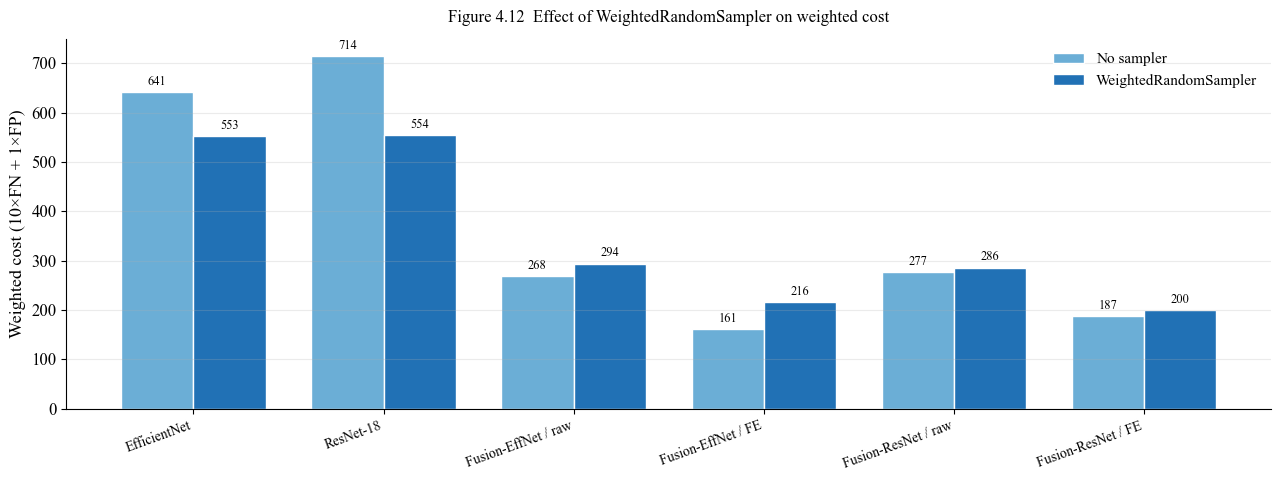

Saved: figures/fig_4_12_sampler_effect.png


In [34]:
# Sampler effect figure
x = np.arange(len(sampler_df)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x-w/2, sampler_df["Cost (no sampler)"], w, label="No sampler",
            color="#6BAED6", edgecolor="white")
b2 = ax.bar(x+w/2, sampler_df["Cost (sampler)"],    w, label="WeightedRandomSampler",
            color="#2171B5", edgecolor="white")
ax.bar_label(b1, labels=[f"{v:,}" for v in sampler_df["Cost (no sampler)"]],
             padding=3, fontsize=9)
ax.bar_label(b2, labels=[f"{v:,}" for v in sampler_df["Cost (sampler)"]],
             padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(sampler_df["Model"], fontsize=10, rotation=20, ha="right")
ax.set_ylabel(COST_LABEL); ax.yaxis.set_major_formatter(fmt_cost)
ax.set_title("Figure 4.12  Effect of WeightedRandomSampler on weighted cost", fontsize=12, pad=12)
ax.legend(frameon=False, fontsize=11)
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_12_sampler_effect.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/fig_4_12_sampler_effect.png")


---
## Section M — Robustness checks

### M.1 isFlaggedFraud ablation

In [35]:
# Load ablation results from notebook 16
ablation_path = paysim_results / "isflaggedfraud_ablation"
ablation_with_path    = paysim_results / "xgb_fe_smote"    / "fe_smote_model.joblib"
ablation_without_path = ablation_path / "model_without_flaggedfraud.joblib"

if ablation_with_path.exists() and ablation_without_path.exists():
    from tabular_xgboost_utils import prepare_dataframes as prepare_xgb2

    data_fe2 = prepare_xgb2(paysim_train, paysim_val, paysim_test,
                             use_feature_engineering=True)
    X_val_fe2  = data_fe2["X_val"];  X_test_fe2 = data_fe2["X_test"]
    X_val_nf   = X_val_fe2.drop(columns=["isFlaggedFraud"])
    X_test_nf  = X_test_fe2.drop(columns=["isFlaggedFraud"])

    model_with    = joblib.load(ablation_with_path)
    model_without = joblib.load(ablation_without_path)

    def eval_ablation(model, X_val, X_test, label):
        thr_df  = search_thresholds(model, X_val, y_val)
        cost_df = compute_cost_table(thr_df, y_val)
        best    = float(cost_df.iloc[0]["threshold"])
        metrics, cm = evaluate_with_threshold(model, X_test, y_test, best)
        tn,fp,fn,tp = np.asarray(cm).ravel()
        cost = int(fn)*FN_WEIGHT + int(fp)*FP_WEIGHT
        print(f"  {label}: thr={best:.2f}  FN={fn}  FP={fp}  cost={cost}")
        return {"model":label,"threshold":best,"fn":int(fn),"fp":int(fp),
                "recall":round(metrics["recall"],4),"weighted_cost":cost}

    print("isFlaggedFraud ablation:")
    r_with    = eval_ablation(model_with,    X_val_fe2, X_test_fe2, "WITH isFlaggedFraud")
    r_without = eval_ablation(model_without, X_val_nf,  X_test_nf,  "WITHOUT isFlaggedFraud")
    abl_df = pd.DataFrame([r_with, r_without])
    abl_df.to_csv(TAB_DIR / "table_4_12_isflagged_ablation.csv", index=False)
    print(f"  Cost difference: {r_without['weighted_cost'] - r_with['weighted_cost']:+,}")
    print("Saved: table_4_12_isflagged_ablation.csv")
else:
    print("Ablation models not found — run notebook 16 first.")


isFlaggedFraud ablation:

Tuned threshold : 0.9500000000000003
  Precision     : 1.000000
  Recall        : 0.997565
  F1            : 0.998781

Confusion matrix:
 [[1270881       0]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

  WITH isFlaggedFraud: thr=0.95  FN=4  FP=0  cost=40

Tuned threshold : 0.9500000000000003
  Precision     : 0.999390
  Recall        : 0.997565
  F1            : 0.998477

Confusion matrix:
 [[1270880       1]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9994    0.9976    0.9985      1643

    accuracy               

### M.2 Type-filtered PaySim model

In [36]:
filter_path = paysim_results / "type_filter_experiment" / "filtered_model.joblib"
if filter_path.exists():
    model_filtered = joblib.load(filter_path)

    # Filtered test set
    fraud_types = paysim_test.groupby("type")["isFraud"].sum()
    fraud_types = fraud_types[fraud_types > 0].index.tolist()
    test_filt   = paysim_test[paysim_test["type"].isin(fraud_types)]

    data_filt = prepare_xgb(
        paysim_train[paysim_train["type"].isin(fraud_types)],
        paysim_val  [paysim_val  ["type"].isin(fraud_types)],
        test_filt, use_feature_engineering=True
    )
    X_val_f2  = data_filt["X_val"];  y_val_f2  = data_filt["y_val"]
    X_test_f2 = data_filt["X_test"]; y_test_f2 = data_filt["y_test"]
    X_test_f2_nf = data_fe["X_test"].drop(columns=["isFlaggedFraud"], errors="ignore")

    thr_df_f   = search_thresholds(model_filtered, X_val_f2, y_val_f2)
    cost_df_f  = compute_cost_table(thr_df_f, y_val_f2)
    best_thr_f = float(cost_df_f.iloc[0]["threshold"])

    # Evaluate on filtered test
    m_filt, cm_filt = evaluate_with_threshold(model_filtered, X_test_f2, y_test_f2, best_thr_f)
    tn,fp,fn,tp = np.asarray(cm_filt).ravel()
    cost_filt   = int(fn)*FN_WEIGHT + int(fp)*FP_WEIGHT

    # Evaluate on full test
    m_full, cm_full = evaluate_with_threshold(model_filtered, X_test_fe, y_test, best_thr_f)
    tn2,fp2,fn2,tp2 = np.asarray(cm_full).ravel()
    cost_full2 = int(fn2)*FN_WEIGHT + int(fp2)*FP_WEIGHT

    type_df = pd.DataFrame([
        {"Scenario":"Full-data model (full test)",       "FN":master_paysim[master_paysim["label"]=="XGB-FE / SMOTE"]["fn"].values[0],
         "FP":master_paysim[master_paysim["label"]=="XGB-FE / SMOTE"]["fp"].values[0],
         "Cost":master_paysim[master_paysim["label"]=="XGB-FE / SMOTE"]["weighted_cost"].values[0]},
        {"Scenario":"Filtered model (filtered test)",    "FN":int(fn), "FP":int(fp), "Cost":cost_filt},
        {"Scenario":"Filtered model (full test — prod)", "FN":int(fn2),"FP":int(fp2),"Cost":cost_full2},
    ])
    print("Table 4.13 — Type-filtered model robustness check")
    print(type_df.to_string(index=False))
    type_df.to_csv(TAB_DIR / "table_4_13_type_filter.csv", index=False)
    print("Saved: table_4_13_type_filter.csv")
else:
    print("Type-filter model not found — run notebook 13 first.")



Tuned threshold : 0.9500000000000003
  Precision     : 1.000000
  Recall        : 0.997565
  F1            : 0.998781

Confusion matrix:
 [[552077      0]
 [     4   1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    552077
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000    553720
   macro avg     1.0000    0.9988    0.9994    553720
weighted avg     1.0000    1.0000    1.0000    553720


Tuned threshold : 0.9500000000000003
  Precision     : 0.993333
  Recall        : 0.997565
  F1            : 0.995445

Confusion matrix:
 [[1270870      11]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9933    0.9976    0.9954      1643

    accuracy                         1.0000   1272524
   macro avg     0.9967    0.9988    0.9977   1272524
w

In [58]:
split_path = nb_results / "split_comparison" / "split_comparison_results.csv"
print(pd.read_csv(split_path))

                experiment   split_type  train_rows  test_rows  overlap  \
0  Old splits\n(random CV)  Old (leaky)        6320       2425      287   
1   New splits\n(group CV)  New (clean)        7182       1474        0   

   best_cv_f1  accuracy  precision    recall        f1   roc_auc  
0    0.920370   0.79134   0.967742  0.690335  0.805833  0.947676  
1    0.916148   0.91791   0.879950  0.967347  0.921581  0.973074  


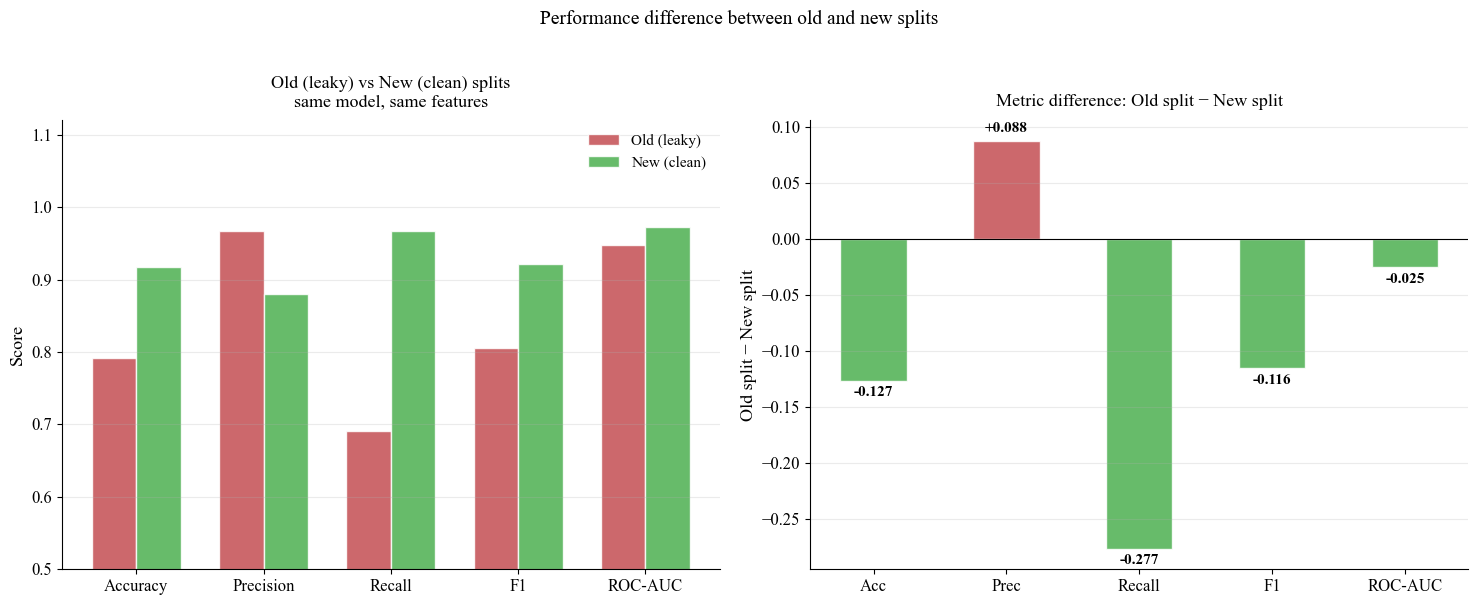

Saved: appendix/fig_appendix_split_comparison.png


In [59]:
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":       14,
    "axes.titlesize":  13,
    "axes.labelsize":  13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

metrics       = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metrics_short = ["Acc", "Prec", "Recall", "F1", "ROC-AUC"]
cols          = ["accuracy", "precision", "recall", "f1", "roc_auc"]

old_vals = [0.79134,  0.967742, 0.690335, 0.805833, 0.947676]
new_vals = [0.91791,  0.879950, 0.967347, 0.921581, 0.973074]
diffs    = [o - n for o, n in zip(old_vals, new_vals)]

x = np.arange(len(metrics)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left panel: grouped bar chart ─────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w/2, old_vals, w, label="Old (leaky)",  color="#C44E52", alpha=0.85, edgecolor="white")
b2 = ax.bar(x + w/2, new_vals, w, label="New (clean)",  color="#4CAF50", alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.12)
ax.set_ylabel("Score")
ax.set_title("Old (leaky) vs New (clean) splits\nsame model, same features", pad=10)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

# ── Right panel: difference chart ─────────────────────────────────────────────
ax = axes[1]
bar_colors = ["#C44E52" if d > 0 else "#4CAF50" for d in diffs]
bars = ax.bar(metrics_short, diffs, color=bar_colors, alpha=0.85,
              edgecolor="white", width=0.5)
ax.bar_label(bars, labels=[f"{d:+.3f}" for d in diffs],
             padding=4, fontsize=11, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Old split − New split")
ax.set_title("Metric difference: Old split − New split", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

fig.suptitle("Performance difference between old and new splits", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(APP_DIR / "fig_appendix_split_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: appendix/fig_appendix_split_comparison.png")

plt.rcParams.update(plt.rcParamsDefault)